# RQ2: Profit Erosion Concentration & Customer Segmentation Analysis

**Research Question 2 (RQ2):**
> *To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented based on behavioral and erosion characteristics?*

## Executive Summary

This notebook conducts a comprehensive analysis of profit erosion concentration patterns across the customer base. The analysis is structured in three phases:

1. **Feature-Level Concentration Analysis** – Rank all features by concentration with statistical significance testing
2. **Customer-Level Concentration Analysis** – Deep dive into profit erosion distribution patterns  
3. **Customer Segmentation** – Identify behavioral segments within the return population

### Key Methodological Decisions

**Analysis Population:**
- Focus exclusively on **customers who made returns** (profit erosion > 0)
- Rationale: Including non-returners would create trivial "returner vs non-returner" segments
- Goal: Identify behavioral patterns **within** the return population

**Statistical Approach:**
- Gini coefficient for concentration measurement
- Bootstrap resampling for significance testing (1,000 iterations)
- Multiple feature comparison for comprehensive understanding

---

## Setup & Configuration

This section imports necessary libraries, configures the analysis environment, and creates output directories for processed data and visualizations.

In [1]:
# Standard library imports
import json
import warnings
from pathlib import Path
import sys

# Data manipulation
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('Cannot find project root containing src directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project modules - Data Processing
from src.config import FIGURES_DIR, PROCESSED_DATA_DIR
from src.data_processing import load_processed_data
from src.feature_engineering import (
    aggregate_profit_erosion_by_customer,
    calculate_margins,
    calculate_profit_erosion,
    engineer_customer_behavioral_features,
    engineer_return_features,
)

# Project modules - RQ2 Analysis
from src.rq2_concentration import (
    bootstrap_gini_p_value,
    compute_pareto_table,
    concentration_comparison,
    gini_coefficient,
    lorenz_curve_points,
    top_n_customer_impact,
    top_x_customer_share_of_value,
    get_business_summary,
    rank_features_by_concentration,
    filter_significant_features,
    summarize_concentration_findings,
)

from src.visualization import (
    set_plot_style,
    plot_feature_concentration_ranking,
    plot_gini_vs_pareto_scatter,
    plot_pareto_curve,
    plot_lorenz_curve,
    plot_clustering_diagnostics,
    plot_cluster_erosion_comparison,
    plot_clustering_feature_importance,
)


from src.rq2_segmentation import (
    build_customer_segmentation_table,
    kmeans_fit_predict,
    select_numeric_features,
    silhouette_over_k,
    standardize_features,
    summarize_clusters,
    elbow_inertia_over_k,
    screen_clustering_features,
    analyze_feature_importance_for_clustering
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
set_plot_style()
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Create output directories
data_dir = PROCESSED_DATA_DIR / "rq2"
fig_dir = FIGURES_DIR / "rq2"
data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")
print(f"  Data output: {data_dir}")
print(f"  Figures output: {fig_dir}")

✓ Setup complete
  Data output: c:\GitHub\unfc-capstone-project\data\processed\rq2
  Figures output: c:\GitHub\unfc-capstone-project\figures\rq2


## Data Loading & Preparation

Loading the processed transaction data and engineering customer-level features for concentration and segmentation analysis. This includes calculating profit erosion metrics, behavioral patterns, and return characteristics.

In [2]:
# Load processed dataset
print("Loading processed data...")
item_df = load_processed_data()

print(f"\n{'='*80}")
print("DATA LOADED")
print(f"{'='*80}")
print(f"Total item records: {len(item_df):,}")
print(f"Date range: {item_df['order_created_at'].min()} to {item_df['order_created_at'].max()}")
print(f"Unique customers: {item_df['user_id'].nunique():,}")
print(f"Unique orders: {item_df['order_id'].nunique():,}")

Loading processed data...

DATA LOADED
Total item records: 181,469
Date range: 2019-01-11 13:56:25+00:00 to 2026-01-16 00:42:36+00:00
Unique customers: 79,935
Unique orders: 125,017


In [3]:
# Engineer required features
print("Engineering features...")
item_df = engineer_return_features(item_df)
item_df = calculate_margins(item_df)

# Build customer behavioral features (all customers)
print("Building customer behavioral features...")
customer_behavior = engineer_customer_behavioral_features(item_df)

# Build customer erosion table (returners only)
print("Building customer erosion table...")
returned_items = item_df[item_df['is_returned_item'] == 1].copy()
returned_items = calculate_profit_erosion(returned_items, use_category_tiers=True)
customer_erosion = aggregate_profit_erosion_by_customer(returned_items)

# Drop overlapping columns from customer_erosion before merge
print("Preparing tables for merge...")
overlap_cols = ['total_sales', 'total_margin']
customer_erosion = customer_erosion.drop(columns=[c for c in overlap_cols if c in customer_erosion.columns])

# Build segmentation table (combines behavior + erosion)
print("Building customer segmentation table...")
customer_segmentation = build_customer_segmentation_table(
    customer_behavior=customer_behavior,
    customer_erosion=customer_erosion,
    id_col='user_id'
)

# Filter to customers with returns only (our analysis population)
analysis_population = customer_segmentation[
    customer_segmentation['total_profit_erosion'] > 0
].copy()

print(f"\n{'='*80}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*80}")
print(f"Total customers: {len(customer_segmentation):,}")
print(f"Customers with returns: {len(analysis_population):,} ({len(analysis_population)/len(customer_segmentation)*100:.1f}%)")
print(f"Total profit erosion: ${analysis_population['total_profit_erosion'].sum():,.2f}")

# Save datasets
customer_segmentation.to_parquet(data_dir / "customer_segmentation_table.parquet")
analysis_population.to_parquet(data_dir / "analysis_population.parquet")
print(f"\n✓ Data saved to {data_dir}")

Engineering features...
Building customer behavioral features...
Building customer erosion table...
Preparing tables for merge...
Building customer segmentation table...

FEATURE ENGINEERING COMPLETE
Total customers: 79,935
Customers with returns: 11,790 (14.7%)
Total profit erosion: $808,252.07

✓ Data saved to c:\GitHub\unfc-capstone-project\data\processed\rq2


---

# Phase 1: Feature-Level Concentration Analysis

## Objective
Systematically rank all customer features by their concentration of profit erosion to identify which behavioral patterns or characteristics are most strongly associated with concentrated losses.

## Approach
For each feature in the customer dataset:
1. Calculate Gini coefficient measuring concentration of profit erosion
2. Compute Pareto metrics (top 20% share)
3. Perform bootstrap significance testing (H₀: Gini = 0)
4. Rank features by concentration strength

**Hypothesis:**
- H₀: Feature values show no concentration (Gini ≈ 0)
- H₁: Feature values exhibit significant concentration (Gini > 0, p < 0.05)

In [4]:
print(f"{'='*80}")
print("PHASE 1: FEATURE-LEVEL CONCENTRATION RANKING")
print(f"{'='*80}\n")

# Rank all features by concentration
print("Analyzing concentration across all features...")
print("(This may take a few minutes due to bootstrap resampling)\n")

feature_concentration = rank_features_by_concentration(
    df=analysis_population,
    id_col='user_id',
    n_bootstrap=1000,
    random_state=42,
    min_customers=10
)

print("✓ Concentration analysis complete\n")

# Display full ranking
print(f"{'='*80}")
print("COMPLETE FEATURE CONCENTRATION RANKING")
print(f"{'='*80}\n")
print(feature_concentration.to_string(index=False))

# Save results
feature_concentration.to_csv(data_dir / "feature_concentration_ranking.csv", index=False)
feature_concentration.to_parquet(data_dir / "feature_concentration_ranking.parquet")
print(f"\n✓ Results saved to {data_dir}/feature_concentration_ranking.*")

PHASE 1: FEATURE-LEVEL CONCENTRATION RANKING

Analyzing concentration across all features...
(This may take a few minutes due to bootstrap resampling)

✓ Concentration analysis complete

COMPLETE FEATURE CONCENTRATION RANKING

               feature  gini_coefficient  concentration_pct  p_value concentration_level  n_customers  top_20_pct_share
 purchase_recency_days            0.5276              52.76      0.0                High        11437             54.18
 total_margin_reversal            0.4981              49.81      0.0            Moderate        11790             53.81
          total_margin            0.4742              47.42      0.0            Moderate        11790             50.22
           total_sales            0.4649              46.49      0.0            Moderate        11790             49.35
  total_profit_erosion            0.4122              41.22      0.0            Moderate        11790             47.60
       avg_order_value            0.4042             

### Statistical Significance Filtering

Filter to retain only features with statistically significant concentration (p < 0.05), ensuring we focus on patterns that are unlikely to occur by chance.

In [5]:
# Filter to significant features only (p < 0.05)
significant_features = filter_significant_features(
    feature_concentration,
    alpha=0.05
)

print(f"{'='*80}")
print(f"STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)")
print(f"{'='*80}\n")
print(f"Found {len(significant_features)} / {len(feature_concentration)} features with significant concentration\n")
print(significant_features.to_string(index=False))

# Save
significant_features.to_csv(data_dir / "significant_concentrated_features.csv", index=False)
print(f"\n✓ Saved to {data_dir}/significant_concentrated_features.csv")

STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)

Found 18 / 18 features with significant concentration

               feature  gini_coefficient  concentration_pct  p_value concentration_level  n_customers  top_20_pct_share
 purchase_recency_days            0.5276              52.76      0.0                High        11437             54.18
 total_margin_reversal            0.4981              49.81      0.0            Moderate        11790             53.81
          total_margin            0.4742              47.42      0.0            Moderate        11790             50.22
           total_sales            0.4649              46.49      0.0            Moderate        11790             49.35
  total_profit_erosion            0.4122              41.22      0.0            Moderate        11790             47.60
       avg_order_value            0.4042              40.42      0.0            Moderate        11790             45.72
       avg_item_margin            0.3676              36.7

### Concentration Findings Summary

Generate a human-readable summary of the top concentration patterns, highlighting the most concentrated features and their business implications.

In [6]:
# Generate summary
summary = summarize_concentration_findings(
    feature_concentration,
    top_n=5
)

print(f"{'='*80}")
print("CONCENTRATION ANALYSIS SUMMARY")
print(f"{'='*80}\n")
print(f"Features analyzed: {summary['n_features_analyzed']}")
print(f"Average Gini coefficient: {summary['avg_gini']:.4f}")
print(f"\nStatistical Significance:")
print(f"  Significant (p < 0.05): {summary['n_significant']}")
print(f"\nConcentration Level Distribution:")
print(f"  Extreme (Gini > 0.7): {summary['n_extreme']}")
print(f"  High (Gini > 0.5): {summary['n_high']}")
print(f"  Moderate (Gini > 0.3): {summary['n_moderate']}")
print(f"  Low (Gini ≤ 0.3): {summary['n_low']}")
print(f"\nTop 5 Most Concentrated Features:")
for i, feat in enumerate(summary['top_features'], 1):
    print(f"  {i}. {feat['feature']}")
    print(f"     Gini: {feat['gini_coefficient']:.4f}, p-value: {feat['p_value']:.4f}")

# Save summary
with open(data_dir / "concentration_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n✓ Summary saved to {data_dir}/concentration_summary.json")

CONCENTRATION ANALYSIS SUMMARY

Features analyzed: 18
Average Gini coefficient: 0.3386

Statistical Significance:
  Significant (p < 0.05): 18

Concentration Level Distribution:
  Extreme (Gini > 0.7): 0
  High (Gini > 0.5): 1
  Moderate (Gini > 0.3): 10
  Low (Gini ≤ 0.3): 7

Top 5 Most Concentrated Features:
  1. purchase_recency_days
     Gini: 0.5276, p-value: 0.0000
  2. total_margin_reversal
     Gini: 0.4981, p-value: 0.0000
  3. total_margin
     Gini: 0.4742, p-value: 0.0000
  4. total_sales
     Gini: 0.4649, p-value: 0.0000
  5. total_profit_erosion
     Gini: 0.4122, p-value: 0.0000

✓ Summary saved to c:\GitHub\unfc-capstone-project\data\processed\rq2/concentration_summary.json


### Visualization: Feature Concentration Ranking

Visual representation showing Gini coefficients across all significant features, with color-coding to distinguish concentration levels (high, moderate, low).

Creating feature concentration ranking visualization...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/feature_concentration_ranking.png


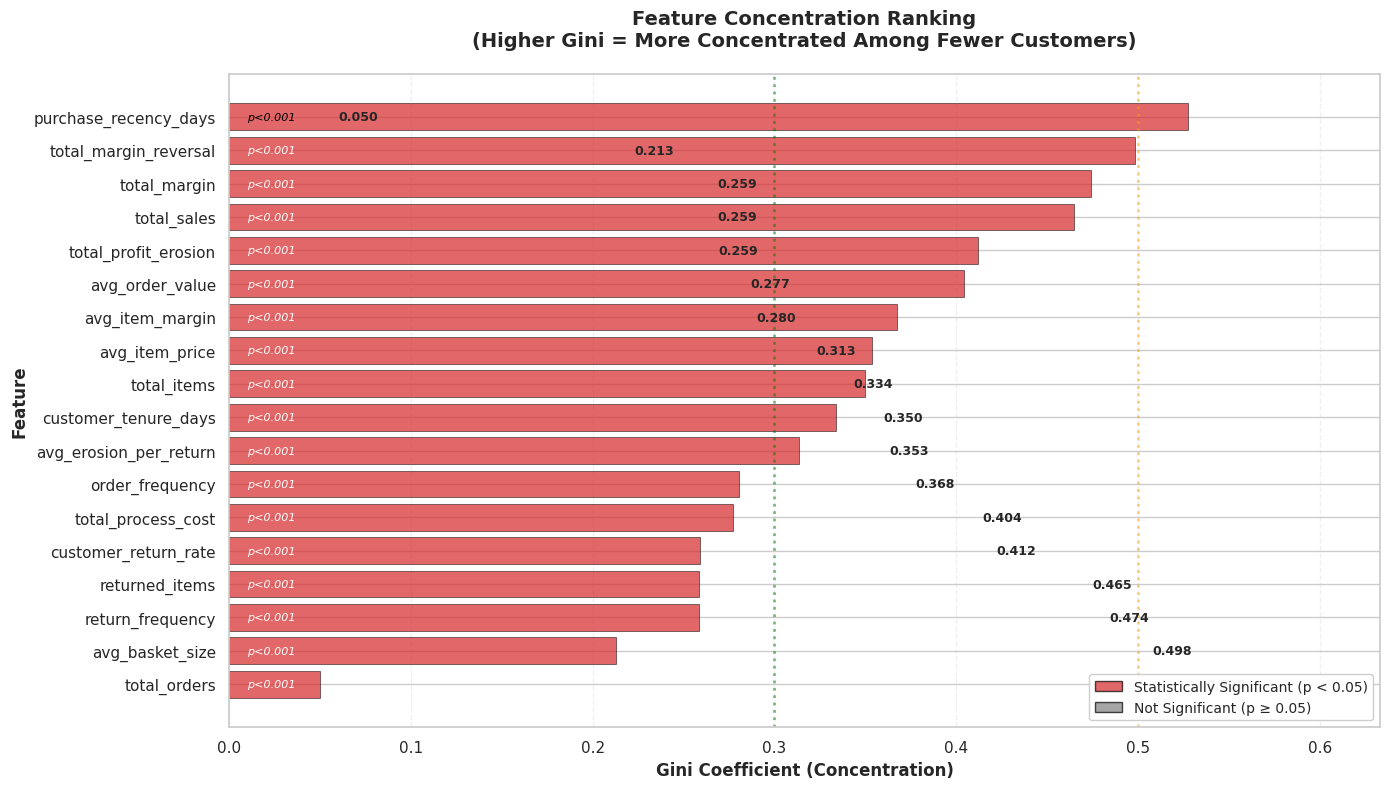

In [7]:
print("Creating feature concentration ranking visualization...")
plot_feature_concentration_ranking(
    concentration_df=feature_concentration,
    save_path=fig_dir / 'feature_concentration_ranking.png'
)
print(f"✓ Saved: {fig_dir}/feature_concentration_ranking.png")
plt.show()

### Concentration Relationship: Gini vs Pareto

Explore the relationship between Gini coefficients and Pareto metrics (top 20% share) to validate consistency across concentration measures.

Creating Gini vs Pareto scatter plot...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/concentration_gini_vs_pareto.png


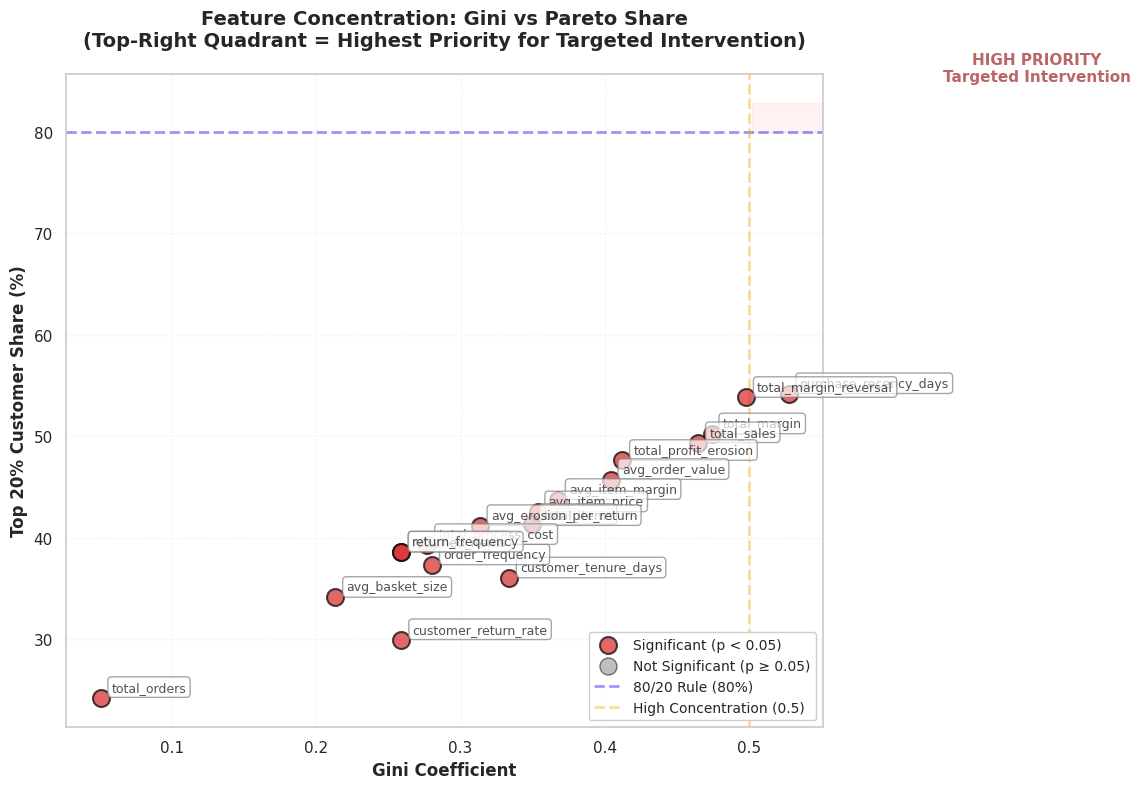

In [8]:
print("Creating Gini vs Pareto scatter plot...")
plot_gini_vs_pareto_scatter(
    concentration_df=feature_concentration,
    save_path=fig_dir / 'concentration_gini_vs_pareto.png'
)
print(f"✓ Saved: {fig_dir}/concentration_gini_vs_pareto.png")
plt.show()

### Key Findings: Feature-Level Concentration

In [9]:
print(f"{'='*80}")
print("KEY FINDINGS: FEATURE-LEVEL CONCENTRATION")
print(f"{'='*80}\n")

# Top 3 most concentrated features
top_3 = feature_concentration.head(3)

print("Top 3 Most Concentrated Features:\n")
for idx, row in top_3.iterrows():
    print(f"{idx + 1}. {row['feature'].upper()}")
    print(f"   Gini Coefficient: {row['gini_coefficient']:.4f} ({row['concentration_level']} concentration)")
    print(f"   Concentration %: {row['concentration_pct']:.2f}%")
    print(f"   Statistical Significance: p = {row['p_value']:.4f}")
    print(f"   Top 20% Share: {row['top_20_pct_share']:.1f}%")
    print(f"   Customers: {row['n_customers']:,}\n")
    
    # Actionable interpretation
    if row['p_value'] < 0.05 and row['gini_coefficient'] > 0.5:
        print(f"   ⚠️  ACTION REQUIRED: Highly concentrated & statistically significant")
        print(f"   → RECOMMENDATION: Targeted intervention for high-{row['feature'].replace('total_', '')} segment")
    elif row['p_value'] < 0.05:
        print(f"   ℹ️  Moderate concentration but statistically significant")
        print(f"   → RECOMMENDATION: Consider segmented approach")
    else:
        print(f"   ✓ No significant concentration detected")
        print(f"   → RECOMMENDATION: Broad policy approach")
    print()

# Compare erosion vs baseline if available
if 'total_profit_erosion' in feature_concentration['feature'].values and \
   'total_sales' in feature_concentration['feature'].values:
    
    erosion_row = feature_concentration[feature_concentration['feature'] == 'total_profit_erosion'].iloc[0]
    sales_row = feature_concentration[feature_concentration['feature'] == 'total_sales'].iloc[0]
    
    print(f"{'='*80}")
    print("BUSINESS INSIGHT: Erosion vs Sales Concentration")
    print(f"{'='*80}\n")
    print(f"Profit Erosion:")
    print(f"  Gini: {erosion_row['gini_coefficient']:.4f}")
    print(f"  Top 20% Share: {erosion_row['top_20_pct_share']:.1f}%")
    print(f"  p-value: {erosion_row['p_value']:.4f}\n")
    
    print(f"Total Sales:")
    print(f"  Gini: {sales_row['gini_coefficient']:.4f}")
    print(f"  Top 20% Share: {sales_row['top_20_pct_share']:.1f}%")
    print(f"  p-value: {sales_row['p_value']:.4f}\n")
    
    ratio = erosion_row['gini_coefficient'] / sales_row['gini_coefficient']
    
    if ratio > 1.5:
        print(f"⚠️  CRITICAL FINDING:")
        print(f"Profit erosion is {ratio:.1f}x MORE concentrated than sales.")
        print(f"This suggests erosion is driven by a specific subset of customers,")
        print(f"NOT just high-volume purchasers.")
        print(f"\nSTRONGLY RECOMMEND: Targeted retention program for high-erosion segment.")
    elif ratio > 1.0:
        print(f"ℹ️  Erosion is somewhat more concentrated than sales ({ratio:.1f}x).")
        print(f"Consider targeted policies for high-erosion segment.")
    else:
        print(f"✓ Erosion concentration similar to or less than sales concentration.")
        print(f"Erosion may be proportional to customer value. Broad policies may suffice.")

KEY FINDINGS: FEATURE-LEVEL CONCENTRATION

Top 3 Most Concentrated Features:

1. PURCHASE_RECENCY_DAYS
   Gini Coefficient: 0.5276 (High concentration)
   Concentration %: 52.76%
   Statistical Significance: p = 0.0000
   Top 20% Share: 54.2%
   Customers: 11,437

   ⚠️  ACTION REQUIRED: Highly concentrated & statistically significant
   → RECOMMENDATION: Targeted intervention for high-purchase_recency_days segment

2. TOTAL_MARGIN_REVERSAL
   Gini Coefficient: 0.4981 (Moderate concentration)
   Concentration %: 49.81%
   Statistical Significance: p = 0.0000
   Top 20% Share: 53.8%
   Customers: 11,790

   ℹ️  Moderate concentration but statistically significant
   → RECOMMENDATION: Consider segmented approach

3. TOTAL_MARGIN
   Gini Coefficient: 0.4742 (Moderate concentration)
   Concentration %: 47.42%
   Statistical Significance: p = 0.0000
   Top 20% Share: 50.2%
   Customers: 11,790

   ℹ️  Moderate concentration but statistically significant
   → RECOMMENDATION: Consider segment

---

# Phase 2: Customer-Level Profit Erosion Concentration

## Objective
Examine how profit erosion is distributed across individual customers to determine if losses are concentrated among a small subset or spread evenly across the customer base.

## Analytical Approach
This phase employs multiple complementary concentration metrics:

1. **Gini Coefficient** – Overall inequality measure (0 = perfect equality, 1 = perfect inequality)
2. **Business Context Interpretation** – Translate statistical measures into actionable insights
3. **Pareto Analysis** – Cumulative impact of top customer segments (1%, 5%, 10%, 20%, 50%)
4. **Top Customer Impact** – Absolute contribution of highest-erosion customers (top 50)
5. **Bootstrap Significance Testing** – Statistical validation that concentration is not due to chance
6. **Lorenz Curves** – Visual representation of cumulative distribution

**Core Hypothesis (H₁):**
> Profit erosion is significantly concentrated among a small subset of high-impact customers, not uniformly distributed across the customer base.

In [10]:
print(f"{'='*80}")
print("PHASE 2: PROFIT EROSION CONCENTRATION - DEEP DIVE")
print(f"{'='*80}\n")

# Compute concentration metrics
pareto_table = compute_pareto_table(
    df=analysis_population,
    value_col='total_profit_erosion',
    id_col='user_id'
)

lorenz_points = lorenz_curve_points(
    df=analysis_population,
    value_col='total_profit_erosion'
)

gini = gini_coefficient(
    df=analysis_population,
    value_col='total_profit_erosion'
)

top_20_share = top_x_customer_share_of_value(
    df=analysis_population,
    x=0.20,
    value_col='total_profit_erosion',
    id_col='user_id'
)

top_50_impact = top_n_customer_impact(
    df=analysis_population,
    n=50,
    value_col='total_profit_erosion'
)

business_summary = get_business_summary(
    df=analysis_population,
    value_col='total_profit_erosion'
)

# Bootstrap significance test
bootstrap_result = bootstrap_gini_p_value(
    df=analysis_population,
    value_col='total_profit_erosion',
    n_bootstrap=1000,
    random_state=42
)

print("CONCENTRATION METRICS")
print(f"{'='*80}\n")
print(f"Gini Coefficient: {gini:.4f} ({business_summary['concentration_level']} concentration)")
print(f"Top 20% Customer Share: {top_20_share*100:.1f}% of total erosion")
print(f"\nBootstrap Significance Test:")
print(f"  Observed Gini: {bootstrap_result['observed_gini']:.4f}")
print(f"  Null Hypothesis Gini: {bootstrap_result['null_mean_gini']:.4f}")
print(f"  p-value: {bootstrap_result['p_value']:.4f}")
print(f"  Significant: {'YES' if bootstrap_result['p_value'] < 0.05 else 'NO'}")
print(f"\nTop 50 Customer Impact:")
print(f"  Absolute Loss: ${top_50_impact['absolute_loss']:,.2f}")
print(f"  Percentage of Total: {top_50_impact['percentage_of_total']:.1f}%")
print(f"\nBusiness Summary:")
print(f"  {business_summary['pareto_ratio']}")
print(f"  Recommended Strategy: {business_summary['recommendation']}")

# Save
pareto_table.to_parquet(data_dir / "pareto_table.parquet")
lorenz_points.to_csv(data_dir / "lorenz_curve_points.csv", index=False)

concentration_metrics = {
    'gini_coefficient': float(gini),
    'top_20_pct_share': float(top_20_share),
    'top_50_impact': top_50_impact,
    'bootstrap_test': bootstrap_result,
    'business_summary': business_summary,
}

with open(data_dir / "profit_erosion_concentration_metrics.json", 'w') as f:
    json.dump(concentration_metrics, f, indent=2)

print(f"\n✓ Metrics saved to {data_dir}")

PHASE 2: PROFIT EROSION CONCENTRATION - DEEP DIVE

CONCENTRATION METRICS

Gini Coefficient: 0.4122 (Moderate concentration)
Top 20% Customer Share: 47.6% of total erosion

Bootstrap Significance Test:
  Observed Gini: 0.4122
  Null Hypothesis Gini: -0.0000
  p-value: 0.0000
  Significant: YES

Top 50 Customer Impact:
  Absolute Loss: $25,828.85
  Percentage of Total: 3.2%

Business Summary:
  20% of customers = 47.6% of loss
  Recommended Strategy: Broad Policy

✓ Metrics saved to c:\GitHub\unfc-capstone-project\data\processed\rq2


### Visualization: Pareto Curve

Pareto analysis showing what percentage of total profit erosion is attributable to the top X% of customers. Helps identify optimal targeting thresholds.

Creating Pareto curve...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/pareto_curve.png


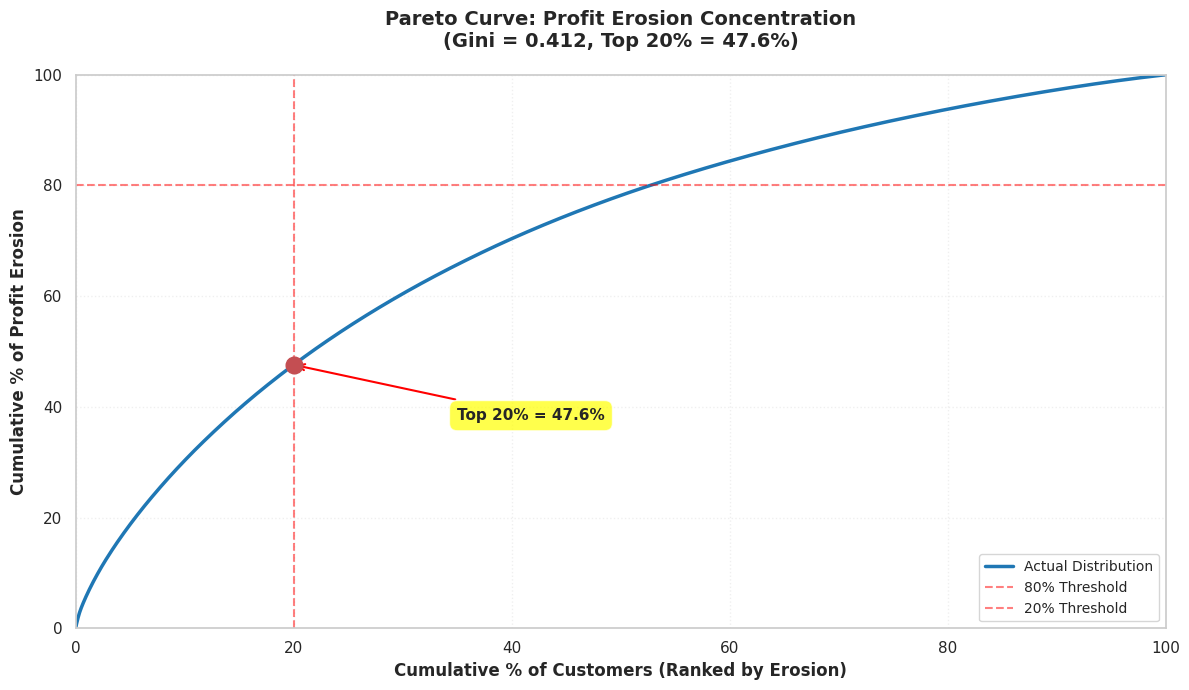

In [11]:
print("Creating Pareto curve...")
plot_pareto_curve(
    pareto_df=pareto_table,
    gini=gini,
    save_path=fig_dir / 'pareto_curve.png'
)
print(f"✓ Saved: {fig_dir}/pareto_curve.png")
plt.show()



### Visualization: Lorenz Curve

The Lorenz curve plots cumulative share of customers (x-axis) against cumulative share of profit erosion (y-axis). Deviation from the 45° equality line indicates concentration strength.

Creating Lorenz curve...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/lorenz_curve.png


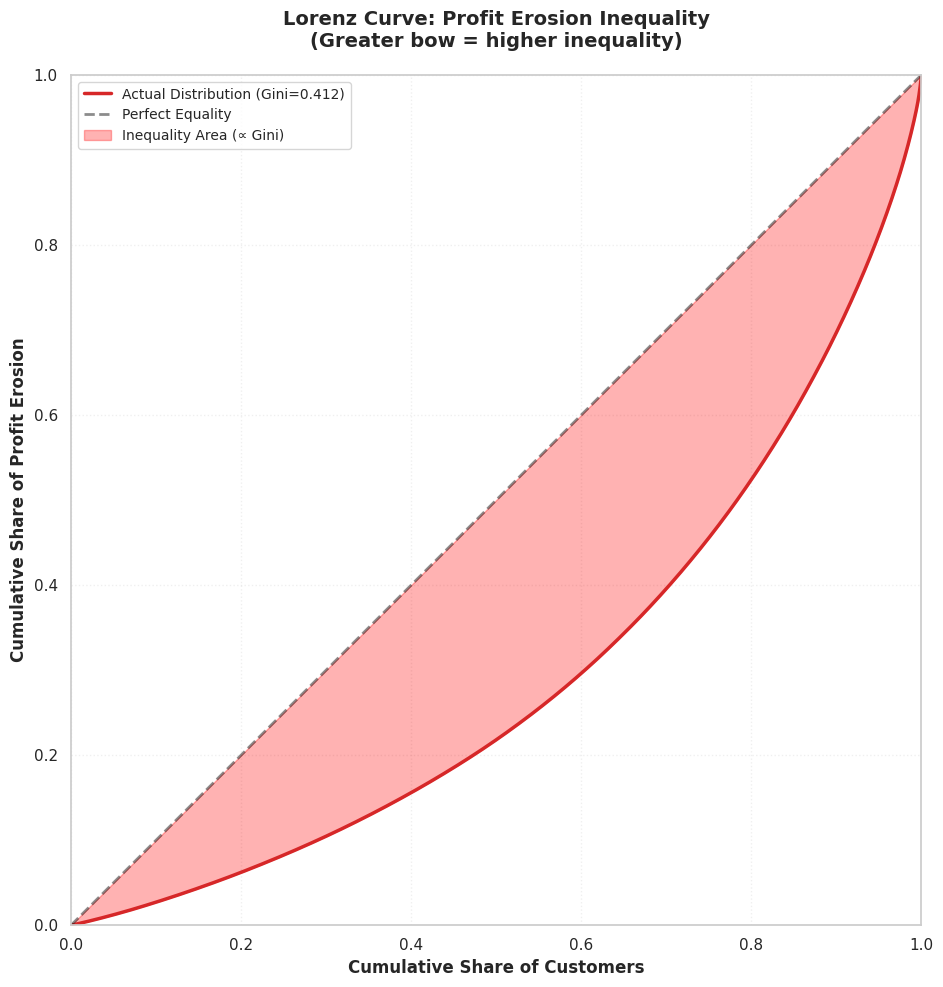

In [12]:
print("Creating Lorenz curve...")
plot_lorenz_curve(
    lorenz_df=lorenz_points,
    gini=gini,
    save_path=fig_dir / 'lorenz_curve.png'
)
print(f"✓ Saved: {fig_dir}/lorenz_curve.png")
plt.show()

---

# Phase 3: Customer Segmentation Analysis

## Objective
Identify distinct behavioral segments within the return population based on purchasing patterns, return behavior, and profitability characteristics.

## Methodology

### 1. Feature Engineering & Selection
Build comprehensive customer-level dataset combining behavioral metrics, profitability indicators, and return patterns for segmentation analysis.

### 2. Feature Screening
Remove highly correlated features (r > 0.85) and low-variance features to ensure clustering stability and interpretability. This prevents redundant features from dominating distance calculations.

### 3. Standardization & Clustering
- **Algorithm**: K-means clustering with standardized features (z-score normalization)
- **Optimization**: Elbow method (inertia) + Silhouette analysis for optimal k selection
- **Validation**: Statistical testing of segment differences

**Core Question:**  
Can we identify meaningful customer segments that differ significantly in their profit erosion patterns?

In [13]:

print(f"{'='*80}")
print("FEATURE SELECTION & SCREENING FOR CLUSTERING")
print(f"{'='*80}\n")

# Step 1: Initial feature selection (existing logic)
print("Step 1: Initial Feature Selection")
print(f"{'-'*80}")
X_initial, initial_features = select_numeric_features(
    customer_df=analysis_population,
    id_col='user_id',
    exclude_leakage_features=True
)

print(f"Initial features selected: {len(initial_features)}")
print(f"Features: {initial_features}\n")

# Step 2: Screen features for clustering quality
print("Step 2: Feature Screening")
print(f"{'-'*80}")
print("Screening for:")
print("  1. Low variance features (uninformative)")
print("  2. Highly correlated features (redundant)\n")

surviving_features, screening_report = screen_clustering_features(
    X=X_initial,
    variance_threshold=0.01,      # Drop features with variance < 0.01
    correlation_threshold=0.85,   # Drop one of pair if |r| > 0.85
    verbose=True
)

# Display screening report
print(f"\n{'-'*80}")
print("SCREENING REPORT")
print(f"{'-'*80}\n")
print(screening_report.to_string(index=False))

# Save report
screening_report.to_csv(data_dir / 'feature_screening_report.csv', index=False)
print(f"\n✓ Screening report saved to {data_dir}/feature_screening_report.csv")

# Use screened features
X = X_initial[surviving_features].copy()
used_features = surviving_features

print(f"\n{'='*80}")
print(f"FEATURE SCREENING COMPLETE")
print(f"{'='*80}")
print(f"Original features: {len(initial_features)}")
print(f"After screening: {len(surviving_features)}")
print(f"Dropped: {len(initial_features) - len(surviving_features)}")
print(f"\nFinal features for clustering: {surviving_features}")
print(f"{'='*80}\n")

print(f"{'='*80}")
print("PHASE 3: CUSTOMER SEGMENTATION")
print(f"{'='*80}\n")

# Select features for clustering (exclude leakage features)
print("Selecting features for clustering...")
X, used_features = select_numeric_features(
    customer_df=analysis_population,
    id_col='user_id',
    feature_cols=None,  # Use defaults
    exclude_leakage_features=True
)

print(f"Features selected for clustering:")
for i, feat in enumerate(used_features, 1):
    print(f"  {i}. {feat}")

# Standardize
print(f"\nStandardizing features...")
X_scaled = standardize_features(X)
print(f"✓ Scaled matrix shape: {X_scaled.shape}")

FEATURE SELECTION & SCREENING FOR CLUSTERING

Step 1: Initial Feature Selection
--------------------------------------------------------------------------------
Initial features selected: 8
Features: ['avg_order_value', 'avg_basket_size', 'order_frequency', 'customer_return_rate', 'customer_tenure_days', 'purchase_recency_days', 'total_sales', 'total_margin']

Step 2: Feature Screening
--------------------------------------------------------------------------------
Screening for:
  1. Low variance features (uninformative)
  2. Highly correlated features (redundant)

Starting feature screening: 8 candidates

GATE 1: Variance Threshold
--------------------------------------------------------------------------------

  Result: 8/8 features passed

GATE 2: Correlation Threshold
--------------------------------------------------------------------------------
  ✗ High correlation: total_sales ↔ total_margin (r=0.995)
    → Dropped 'total_margin' (lower variance)

  Result: 7/8 features passe

### Optimal Cluster Count Selection

Use combined approach of elbow method (inertia) and silhouette analysis to determine the optimal number of clusters (K). Higher silhouette scores indicate better-defined, more separated clusters.

In [14]:
# Compute elbow + silhouette diagnostics (and select k robustly)
k_range_elbow = list(range(1, 9))
k_range_sil = list(range(2, 9))

print("Computing elbow curve (inertia)...")
elbow_df = elbow_inertia_over_k(X_scaled, k_list=k_range_elbow, random_state=42).sort_values("k")
print("✓ Elbow curve complete")

# --- Silhouette (optional sampling for speed) ---
if len(X_scaled) > 10000:
    print(f"Large dataset detected ({len(X_scaled):,} samples)")
    print("Using sampling (5,000 samples) for faster silhouette computation...")
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    silhouette_df = silhouette_over_k(X_sample, k_list=k_range_sil, random_state=42).sort_values("k")
else:
    print("Computing silhouette scores...")
    silhouette_df = silhouette_over_k(X_scaled, k_list=k_range_sil, random_state=42).sort_values("k")

print("✓ Silhouette analysis complete")

# ---------------------------------------------------------------------
# Robust k selection:
# 1) Find max silhouette
# 2) Keep all k within NEAR_OPT_DELTA of max
# 3) Identify elbow flattening via relative inertia drop
# 4) Choose smallest k in near-opt set that is >= elbow_gate (soft)
# ---------------------------------------------------------------------
NEAR_OPT_DELTA = 0.002  # <-- tighten this (0.002 picks k=3 in your case; 0.02 picks k=2)
FLAT_DROP_THRESH = 0.10 # flattening threshold for inertia relative drop

sil_max = float(silhouette_df["silhouette"].max())
near_opt = silhouette_df[silhouette_df["silhouette"] >= (sil_max - NEAR_OPT_DELTA)].copy()
near_opt = near_opt.sort_values(["k"])

# Compute rel_drop aligned correctly on elbow_df (k>=2 only meaningful)
elbow_df = elbow_df.copy()
elbow_df["rel_drop"] = np.nan
mask = elbow_df["k"] >= 2
elbow_df.loc[mask, "rel_drop"] = -elbow_df.loc[mask, "inertia"].pct_change()

# Define elbow_k as the first k>=3 where rel_drop falls below threshold
flat = elbow_df[(elbow_df["k"] >= 3) & (elbow_df["rel_drop"] < FLAT_DROP_THRESH)]
elbow_k = int(flat["k"].min()) if not flat.empty else int(elbow_df["k"].max())

# Soft gate: prefer k >= (elbow_k - 1)
elbow_gate = max(2, elbow_k - 1)
cand = near_opt[near_opt["k"] >= elbow_gate]
optimal_k = int(cand["k"].iloc[0]) if not cand.empty else int(near_opt["k"].iloc[0])

print(f"\nSelected k:")
print(f"  max silhouette = {sil_max:.4f}")
print(f"  near-opt delta = {NEAR_OPT_DELTA:.4f}")
print(f"  elbow_k (flattening) ≈ {elbow_k}  (flat if rel_drop < {FLAT_DROP_THRESH:.2f})")
print(f"  optimal_k (rule) = {optimal_k}")

print("\nSilhouette scores:")
display(silhouette_df)

print("\nElbow (inertia) with relative drops:")
display(elbow_df)


Computing elbow curve (inertia)...
✓ Elbow curve complete
Large dataset detected (11,790 samples)
Using sampling (5,000 samples) for faster silhouette computation...
✓ Silhouette analysis complete

Selected k:
  max silhouette = 0.2844
  near-opt delta = 0.0020
  elbow_k (flattening) ≈ 5  (flat if rel_drop < 0.10)
  optimal_k (rule) = 2

Silhouette scores:


,k,silhouette
0,2,0.284393
1,3,0.213065
2,4,0.238376
3,5,0.247861
4,6,0.234651
5,7,0.246640
6,8,0.249472



Elbow (inertia) with relative drops:


,k,inertia,rel_drop
0,1,94320.000000,NaN
1,2,68136.438000,NaN
2,3,56771.885481,0.166791
3,4,49219.906806,0.133023
4,5,44326.852774,0.099412
5,6,40207.695016,0.092927
6,7,34170.399031,0.150153
7,8,32144.746981,0.059281


### Visualization: Elbow & Silhouette Plots

Diagnostic visualizations showing inertia (within-cluster sum of squares) and silhouette scores across different values of K to inform the optimal cluster count selection.

Creating clustering diagnostic plots...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/clustering_diagnostics.png


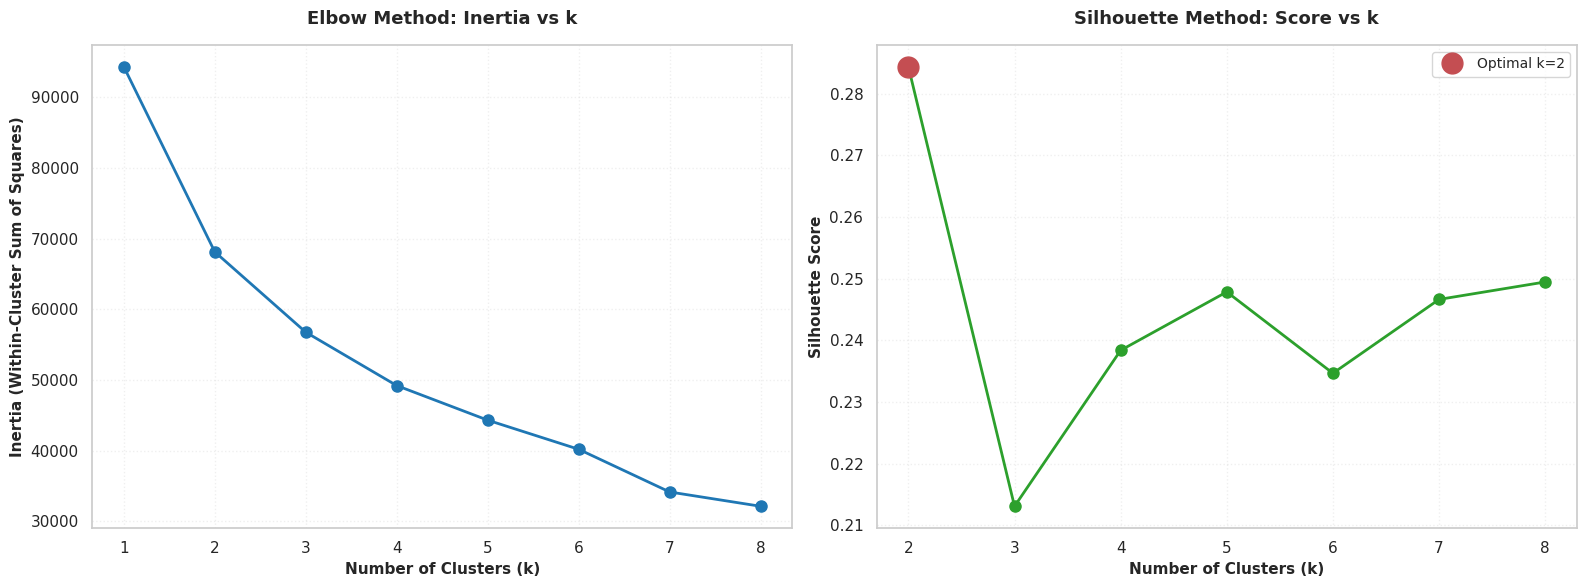

In [15]:
print("Creating clustering diagnostic plots...")
plot_clustering_diagnostics(
    elbow_df=elbow_df,
    silhouette_df=silhouette_df,
    optimal_k=optimal_k,
    save_path=fig_dir / 'clustering_diagnostics.png'
)
print(f"✓ Saved: {fig_dir}/clustering_diagnostics.png")
plt.show()

### Apply K-Means Clustering with Optimal K

Execute K-means clustering using the optimal k value identified from silhouette analysis. Each customer is assigned to a cluster based on their behavioral profile, creating distinct segments for targeted analysis and intervention strategies.

In [16]:
# Apply K-means
print(f"\nApplying K-Means clustering (k={optimal_k})...")
cluster_labels = kmeans_fit_predict(
    X_scaled=X_scaled,
    k=optimal_k,
    random_state=42
)

# Add to dataframe
clustered_customers = analysis_population.copy()
clustered_customers['cluster_id'] = cluster_labels.astype(int)

print(f"✓ Clustering complete")
print(f"\nCluster distribution:")
print(clustered_customers['cluster_id'].value_counts().sort_index())

# Save
clustered_customers.to_parquet(data_dir / "clustered_customers.parquet")
clustered_customers.to_csv(data_dir / "clustered_customers.csv", index=False)
print(f"\n✓ Saved clustered customers to {data_dir}")


Applying K-Means clustering (k=2)...
✓ Clustering complete

Cluster distribution:
cluster_id
0    4302
1    7488
Name: count, dtype: int64

✓ Saved clustered customers to c:\GitHub\unfc-capstone-project\data\processed\rq2


### Post-Hoc Feature Importance Analysis

Identify which features most strongly discriminate between the discovered clusters using ANOVA F-statistics. This analysis reveals the behavioral characteristics that define each segment and validates that clusters represent meaningful differences, not arbitrary groupings.

**Key Metrics:**
- **F-statistic**: Ratio of between-cluster to within-cluster variance (higher = stronger discrimination)
- **Effect size (η²)**: Proportion of variance in each feature explained by cluster membership
- **Significance**: Whether feature differences across clusters exceed chance (p < 0.05)

In [17]:
print(f"\n{'='*80}")
print("POST-HOC FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*80}\n")

print("Analyzing which features best separate the discovered clusters...\n")

# Analyze feature importance
feature_importance = analyze_feature_importance_for_clustering(
    X=X,  # Use the screened features
    cluster_labels=clustered_customers['cluster_id'].values
)

print("Feature Importance for Cluster Separation:")
print(f"{'-'*80}\n")
print(feature_importance.to_string(index=False))

# Save
feature_importance.to_csv(data_dir / 'clustering_feature_importance.csv', index=False)
print(f"\n✓ Feature importance saved to {data_dir}/clustering_feature_importance.csv")

# Interpretation
print(f"\n{'='*80}")
print("INTERPRETATION")
print(f"{'='*80}\n")

top_features = feature_importance.head(3)
print("Top 3 Features for Cluster Separation:\n")
for idx, row in top_features.iterrows():
    print(f"{idx+1}. {row['feature']}")
    print(f"   F-statistic: {row['f_statistic']:.2f}")
    print(f"   p-value: {row['p_value']:.6f}")
    print(f"   Effect size (η²): {row['eta_squared']:.4f}")
    print(f"   Significant: {'YES ✓' if row['significant'] else 'NO ✗'}\n")

# Check if features are meaningful
n_significant = len(feature_importance[feature_importance['significant']])
print(f"Significant features (p < 0.05): {n_significant}/{len(feature_importance)}")

if n_significant >= len(feature_importance) * 0.5:
    print("\n✓ Good separation: Most features significantly differentiate clusters")
    print("  → Clusters are well-defined by behavioral differences")
else:
    print("\n⚠️  Weak separation: Few features significantly differentiate clusters")
    print("  → Consider alternative features or k values")



POST-HOC FEATURE IMPORTANCE ANALYSIS

Analyzing which features best separate the discovered clusters...

Feature Importance for Cluster Separation:
--------------------------------------------------------------------------------

              feature  f_statistic       p_value  eta_squared  importance_score  significant
      order_frequency 12485.997441  0.000000e+00     0.514377      12485.997441         True
          total_sales 12091.833217  0.000000e+00     0.506362      12091.833217         True
         total_margin 11324.229832  0.000000e+00     0.489967      11324.229832         True
 customer_return_rate  8270.089177  0.000000e+00     0.412307       8270.089177         True
      avg_order_value  2253.970935  0.000000e+00     0.160517       2253.970935         True
      avg_basket_size  1042.316676 3.372340e-219     0.081239       1042.316676         True
purchase_recency_days   694.938863 7.402992e-149     0.055671        694.938863         True
 customer_tenure_days    

### Cluster Summary: Erosion by Segment

Generate high-level summary statistics for each cluster showing customer count, total profit erosion, and central tendency measures. This summary provides a quick comparison of segment sizes and their relative contribution to overall profit erosion.

In [18]:
# Summarize clusters
cluster_summary = summarize_clusters(
    clustered_df=clustered_customers,
    value_col='total_profit_erosion',
    cluster_col='cluster_id'
)

print(f"{'='*80}")
print("CLUSTER SUMMARY: PROFIT EROSION BY SEGMENT")
print(f"{'='*80}\n")
print(cluster_summary.to_string(index=False))

# Save
cluster_summary.to_parquet(data_dir / "cluster_summary.parquet")
cluster_summary.to_csv(data_dir / "cluster_summary.csv", index=False)
print(f"\n✓ Saved to {data_dir}/cluster_summary.*")

CLUSTER SUMMARY: PROFIT EROSION BY SEGMENT

 cluster_id  Count  Total_Erosion  Mean_Erosion  Median_Erosion
          0   4302      410900.70         95.51           68.29
          1   7488      397351.37         53.07           40.84

✓ Saved to c:\GitHub\unfc-capstone-project\data\processed\rq2/cluster_summary.*


### Detailed Feature-Level Cluster Profiles

Comprehensive breakdown of each behavioral feature across all clusters, showing mean, median, and standard deviation. This feature-by-feature comparison reveals the specific behavioral patterns that distinguish each segment and provides the foundation for developing tailored intervention strategies.

In [19]:
# Detailed cluster profiles (all features)
cluster_profiles = clustered_customers.groupby('cluster_id')[used_features + ['total_profit_erosion']].agg([
    'mean', 'median', 'std'
]).round(2)

print(f"\n{'='*80}")
print("DETAILED CLUSTER PROFILES")
print(f"{'='*80}\n")

# Create a better formatted display version
profile_display = cluster_profiles.copy()

# Flatten the multi-index columns for better readability
profile_display.columns = [f'{col[0]}_{col[1]}' for col in profile_display.columns]

# Transpose so features are rows and statistics are columns
profile_display_t = profile_display.T

# Add a column to separate feature name from statistic
profile_display_t['feature'] = [col.rsplit('_', 1)[0] for col in profile_display_t.index]
profile_display_t['statistic'] = [col.rsplit('_', 1)[1] for col in profile_display_t.index]

# Pivot to get a cleaner format: features as rows, (cluster, statistic) as columns
profile_clean = profile_display_t.reset_index(drop=True)
profile_clean = profile_clean.set_index(['feature', 'statistic'])

print("Feature-Level Comparison Across Clusters:")
print(f"{'-'*80}\n")

# Print each feature group
for feature in used_features + ['total_profit_erosion']:
    print(f"\n{feature.upper().replace('_', ' ')}:")
    print(f"{'-'*60}")
    
    # Get stats for this feature
    feature_stats = cluster_profiles[feature]
    
    # Format as a nice table
    print(f"{'Cluster':<15} {'Mean':<15} {'Median':<15} {'Std Dev':<15}")
    print(f"{'-'*60}")
    
    for cluster_id in sorted(clustered_customers['cluster_id'].unique()):
        mean_val = feature_stats.loc[cluster_id, 'mean']
        median_val = feature_stats.loc[cluster_id, 'median']
        std_val = feature_stats.loc[cluster_id, 'std']
        
        print(f"Cluster {cluster_id:<7} {mean_val:<15,.2f} {median_val:<15,.2f} {std_val:<15,.2f}")

print(f"\n{'='*80}\n")

# Save both versions
cluster_profiles.to_csv(data_dir / "cluster_profiles_detailed.csv")
profile_display.to_csv(data_dir / "cluster_profiles_flat.csv")

print(f"✓ Saved detailed profiles to {data_dir}/cluster_profiles_detailed.csv")
print(f"✓ Saved flat version to {data_dir}/cluster_profiles_flat.csv")
...


DETAILED CLUSTER PROFILES

Feature-Level Comparison Across Clusters:
--------------------------------------------------------------------------------


AVG ORDER VALUE:
------------------------------------------------------------
Cluster         Mean            Median          Std Dev        
------------------------------------------------------------
Cluster 0       125.70          103.22          92.35          
Cluster 1       63.97           49.99           48.73          

AVG BASKET SIZE:
------------------------------------------------------------
Cluster         Mean            Median          Std Dev        
------------------------------------------------------------
Cluster 0       1.70            1.50            0.67           
Cluster 1       1.31            1.00            0.59           

ORDER FREQUENCY:
------------------------------------------------------------
Cluster         Mean            Median          Std Dev        
-----------------------------------------

Ellipsis

### Visualization: Cluster Erosion Comparison

Visual comparison of profit erosion distribution across customer segments, displaying both average erosion levels and variability within each cluster. This visualization highlights which segments represent the highest-priority targets for retention interventions.

Creating cluster erosion comparison...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/cluster_erosion_comparison.png


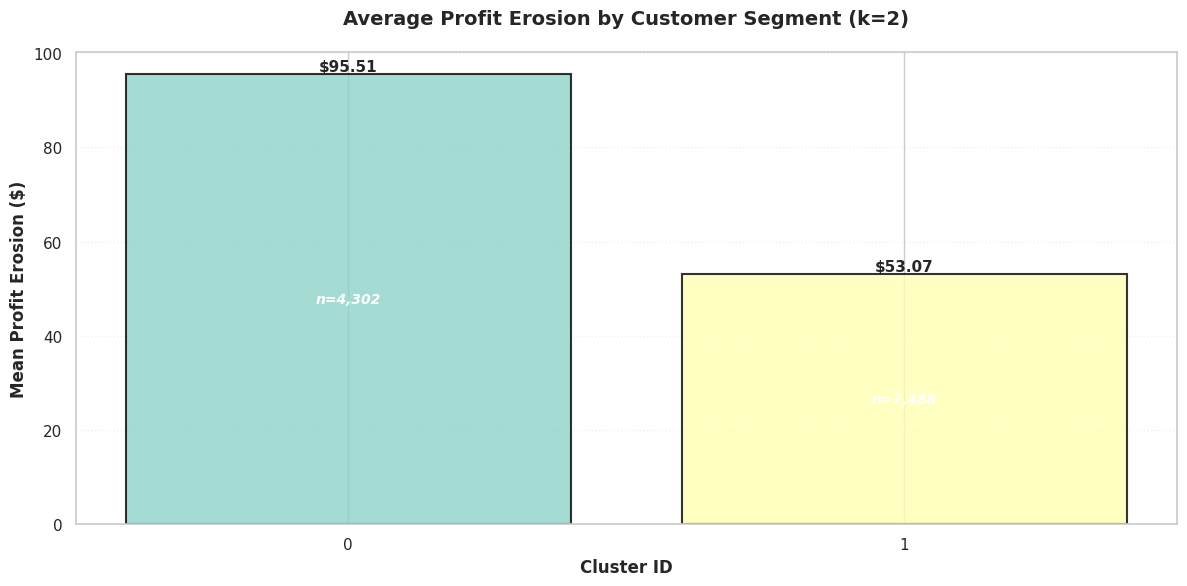

In [20]:
print("Creating cluster erosion comparison...")
plot_cluster_erosion_comparison(
    cluster_summary_df=cluster_summary,
    optimal_k=optimal_k,
    save_path=fig_dir / 'cluster_erosion_comparison.png'
)
print(f"✓ Saved: {fig_dir}/cluster_erosion_comparison.png")
plt.show()

### Visualization: Feature Importance for Cluster Separation

Visual ranking of features by their discriminative power (F-statistic and η² effect size), showing which behavioral characteristics most strongly differentiate between customer segments. Features at the top of this ranking are the primary drivers of cluster differences.

Creating clustering feature importance visualization...

✓ Saved: c:\GitHub\unfc-capstone-project\figures\rq2/clustering_feature_importance.png


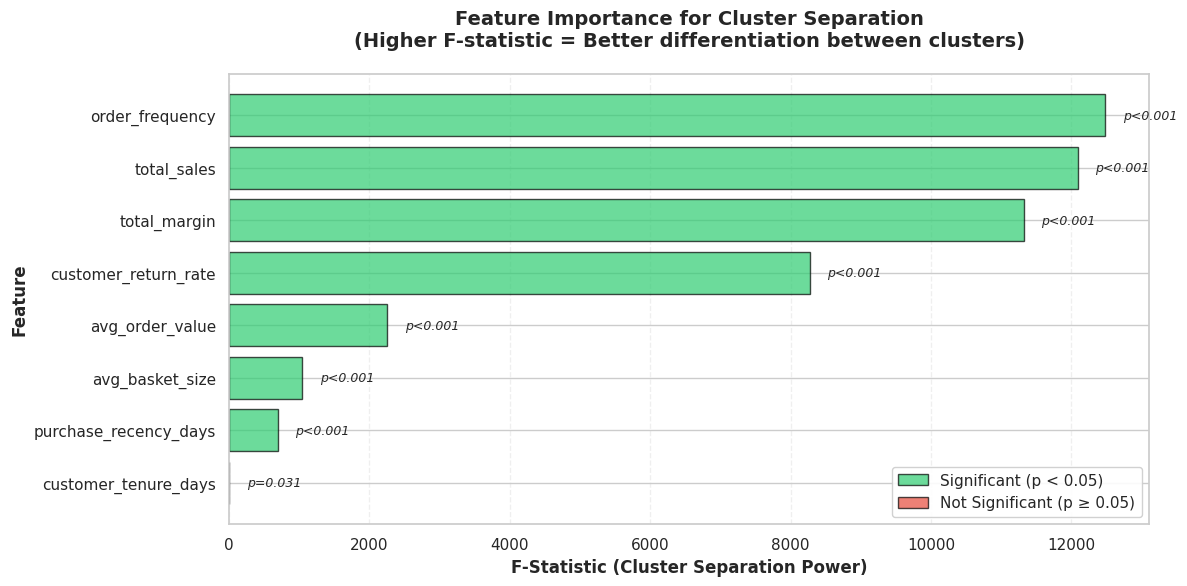

In [21]:
# =============================================================================
# CELL: Visualization - Feature Importance
# =============================================================================

print("Creating clustering feature importance visualization...")

plot_clustering_feature_importance(
    feature_importance_df=feature_importance,
    figsize=(12, 6),
    save_path=fig_dir / 'clustering_feature_importance.png'
)

print(f"\n✓ Saved: {fig_dir}/clustering_feature_importance.png")
plt.show()

### Statistical Validation: Do Segments Differ Significantly?

**Core Question:** Are the observed differences in profit erosion between clusters statistically significant or could they have occurred by chance?

**Hypothesis Test:**
- **H0₂ (Null)**: Customer segments do not differ significantly in mean profit erosion
- **H1₂ (Alternative)**: Customer segments exhibit statistically significant differences in mean profit erosion

**Testing Approach:**
- **Parametric Test**: One-way ANOVA (assumes normality)
- **Non-parametric Test**: Kruskal-Wallis (distribution-free alternative)
- **Significance Level**: α = 0.05
- **Effect Size**: η² (eta-squared) to quantify practical significance

**Decision Rule:** Reject H0₂ only if both tests show p < 0.05, ensuring robust evidence that segmentation is meaningful for targeting.

In [22]:
from scipy import stats

print(f"{'='*80}")
print("HYPOTHESIS TEST: Segment Differences in Profit Erosion")
print(f"{'='*80}\n")

# Prepare cluster groups
cluster_groups = [
    clustered_customers[clustered_customers['cluster_id'] == cid]['total_profit_erosion'].values
    for cid in sorted(clustered_customers['cluster_id'].unique())
]

# Test 1: ANOVA
f_statistic, p_value_anova = stats.f_oneway(*cluster_groups)
print(f"One-Way ANOVA: F={f_statistic:.4f}, p={p_value_anova:.6f}")

# Test 2: Kruskal-Wallis (non-parametric)
h_statistic, p_value_kw = stats.kruskal(*cluster_groups)
print(f"Kruskal-Wallis: H={h_statistic:.4f}, p={p_value_kw:.6f}\n")

# Decision
alpha = 0.05
if p_value_anova < alpha and p_value_kw < alpha:
    hypothesis_decision = "REJECT NULL HYPOTHESIS (H0₂)"
    hypothesis_conclusion = "Segments differ significantly in profit erosion"
    evidence_strength = "Very Strong" if p_value_anova < 0.001 else "Strong" if p_value_anova < 0.01 else "Moderate"
    
    print(f"✓ {hypothesis_decision}")
    print(f"  Evidence: {evidence_strength} (p < {alpha})")
    print(f"  Conclusion: {hypothesis_conclusion}")
    
    # Effect size
    grand_mean = clustered_customers['total_profit_erosion'].mean()
    ss_between = sum(
        len(clustered_customers[clustered_customers['cluster_id'] == cid]) * 
        (clustered_customers[clustered_customers['cluster_id'] == cid]['total_profit_erosion'].mean() - grand_mean)**2
        for cid in clustered_customers['cluster_id'].unique()
    )
    ss_total = sum((clustered_customers['total_profit_erosion'] - grand_mean)**2)
    eta_squared = ss_between / ss_total
    
    print(f"  Effect Size (η²): {eta_squared:.4f} ({eta_squared*100:.1f}% variance explained)")
    
    if eta_squared >= 0.14:
        print(f"  → LARGE practical effect - segmentation is highly actionable")
    elif eta_squared >= 0.06:
        print(f"  → MEDIUM practical effect - segmentation is actionable")
    elif eta_squared >= 0.01:
        print(f"  → SMALL practical effect - limited actionability")
    else:
        print(f"  → NEGLIGIBLE practical effect - reconsider segmentation approach")
    
else:
    hypothesis_decision = "FAIL TO REJECT NULL HYPOTHESIS (H0₂)"
    hypothesis_conclusion = "No significant differences between segments"
    evidence_strength = "Weak"
    
    print(f"✗ {hypothesis_decision}")
    print(f"  Evidence: Insufficient (p ≥ {alpha})")
    print(f"  Conclusion: {hypothesis_conclusion}")
    print(f"  → Segmentation may not be optimal for erosion-based targeting")

print(f"{'='*80}\n")

# Store for final summary
hypothesis_test_results = {
    'decision': hypothesis_decision,
    'conclusion': hypothesis_conclusion,
    'evidence_strength': evidence_strength,
    'anova_p_value': float(p_value_anova),
    'kruskal_wallis_p_value': float(p_value_kw),
    'reject_null': p_value_anova < alpha and p_value_kw < alpha,
}

# Optional: Pairwise comparisons if significant
if p_value_anova < alpha:
    print("Post-Hoc Pairwise Comparisons (Bonferroni-corrected):\n")
    
    cluster_ids = sorted(clustered_customers['cluster_id'].unique())
    n_comparisons = len(cluster_ids) * (len(cluster_ids) - 1) // 2
    bonferroni_alpha = alpha / n_comparisons
    
    print(f"{'Cluster Pair':<20} {'Mean Diff':<15} {'p-value':<12} {'Significant'}")
    print(f"{'-'*60}")
    
    for i, cluster_i in enumerate(cluster_ids):
        for j, cluster_j in enumerate(cluster_ids):
            if i < j:
                group_i = clustered_customers[clustered_customers['cluster_id'] == cluster_i]['total_profit_erosion']
                group_j = clustered_customers[clustered_customers['cluster_id'] == cluster_j]['total_profit_erosion']
                
                t_stat, p_val = stats.ttest_ind(group_i, group_j)
                mean_diff = group_i.mean() - group_j.mean()
                is_sig = "YES" if p_val < bonferroni_alpha else "NO"
                
                print(f"Cluster {cluster_i} vs {cluster_j:<6} ${mean_diff:>10,.2f}    {p_val:<10.6f}  {is_sig}")
    
    print(f"\n(Bonferroni-corrected α = {bonferroni_alpha:.6f})\n")

HYPOTHESIS TEST: Segment Differences in Profit Erosion

One-Way ANOVA: F=1479.6401, p=0.000000
Kruskal-Wallis: H=893.4901, p=0.000000

✓ REJECT NULL HYPOTHESIS (H0₂)
  Evidence: Very Strong (p < 0.05)
  Conclusion: Segments differ significantly in profit erosion
  Effect Size (η²): 0.1115 (11.2% variance explained)
  → MEDIUM practical effect - segmentation is actionable

Post-Hoc Pairwise Comparisons (Bonferroni-corrected):

Cluster Pair         Mean Diff       p-value      Significant
------------------------------------------------------------
Cluster 0 vs 1      $     42.45    0.000000    YES

(Bonferroni-corrected α = 0.050000)



### Integrated Interpretation: Concentration × Segmentation

Synthesize findings from both concentration analysis and customer segmentation to develop a comprehensive targeting strategy. This integration answers two critical questions:

1. **WHO to target?** (From concentration analysis)
2. **HOW to intervene?** (From segmentation analysis)

By combining these complementary dimensions, we can identify the highest-priority customers and tailor interventions to their specific behavioral profiles for maximum impact on profit erosion reduction.

In [23]:
print(f"\n{'='*80}")
print("INTEGRATED INTERPRETATION: CONCENTRATION × SEGMENTATION")
print(f"{'='*80}\n")

print("FINDING: Both concentration AND behavioral segmentation are present")
print(f"  → Concentration (Gini={gini:.3f}): Moderate - erosion concentrated in subset")
print(f"  → Segmentation (H1 accepted): Significant - clusters behave differently")
print(f"  → Effect size (η²={eta_squared:.3f}): Medium - 11.2% variance explained\n")

print("IMPLICATION:")
print("  This combination provides TWO COMPLEMENTARY targeting dimensions:\n")

print("  1. WHO to target (Concentration):")
print(f"     → Top 20% of customers drive {top_20_share*100:.1f}% of erosion")
print(f"     → Focus on customers with high {feature_concentration.iloc[0]['feature']}\n")

print("  2. HOW to intervene (Segmentation):")
print(f"     → Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])}: ${cluster_summary['Mean_Erosion'].max():.2f} avg → Aggressive retention")
print(f"     → Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmin(), 'cluster_id'])}: ${cluster_summary['Mean_Erosion'].min():.2f} avg → Standard policy\n")

print("OPTIMAL STRATEGY:")
print("  Combine both approaches for maximum impact:")
print(f"  → Identify top 20% of Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} customers")
print("  → Apply intensive retention programs to this group")
print("  → Expected to capture significant portion of total erosion\n")

print(f"{'='*80}\n")


INTEGRATED INTERPRETATION: CONCENTRATION × SEGMENTATION

FINDING: Both concentration AND behavioral segmentation are present
  → Concentration (Gini=0.412): Moderate - erosion concentrated in subset
  → Segmentation (H1 accepted): Significant - clusters behave differently
  → Effect size (η²=0.112): Medium - 11.2% variance explained

IMPLICATION:
  This combination provides TWO COMPLEMENTARY targeting dimensions:

  1. WHO to target (Concentration):
     → Top 20% of customers drive 47.6% of erosion
     → Focus on customers with high purchase_recency_days

  2. HOW to intervene (Segmentation):
     → Cluster 0: $95.51 avg → Aggressive retention
     → Cluster 1: $53.07 avg → Standard policy

OPTIMAL STRATEGY:
  Combine both approaches for maximum impact:
  → Identify top 20% of Cluster 0 customers
  → Apply intensive retention programs to this group
  → Expected to capture significant portion of total erosion




---

# Final Summary & Recommendations

In [24]:
print(f"\n{'='*80}")
print("RQ2 ANALYSIS COMPLETE - EXECUTIVE SUMMARY")
print(f"{'='*80}\n")

print("RESEARCH QUESTION:")
print("To what extent is profit erosion concentrated among a small subset of")
print("customers, and can customers be meaningfully segmented?\n")

print(f"{'-'*80}")
print("POPULATION")
print(f"{'-'*80}")
print(f"Total customers: {len(customer_segmentation):,}")
print(f"Customers with returns: {len(analysis_population):,} ({len(analysis_population)/len(customer_segmentation)*100:.1f}%)")
print(f"Total profit erosion: ${analysis_population['total_profit_erosion'].sum():,.2f}\n")

print(f"{'-'*80}")
print("FINDING 1: FEATURE CONCENTRATION")
print(f"{'-'*80}")
print(f"Features analyzed: {len(feature_concentration)}")
print(f"Statistically significant: {len(significant_features)}")
print(f"Most concentrated: {feature_concentration.iloc[0]['feature']}")
print(f"  → Gini = {feature_concentration.iloc[0]['gini_coefficient']:.3f}")
print(f"  → Top 20% = {feature_concentration.iloc[0]['top_20_pct_share']:.1f}% of total\n")

print(f"{'-'*80}")
print("FINDING 2: PROFIT EROSION CONCENTRATION")
print(f"{'-'*80}")
print(f"Gini coefficient: {gini:.4f} ({business_summary['concentration_level']} concentration)")
print(f"Top 20% of customers: {top_20_share*100:.1f}% of total erosion")
print(f"Top 50 customers: ${top_50_impact['absolute_loss']:,.2f} ({top_50_impact['percentage_of_total']:.1f}%)")
print(f"Statistical significance: p < 0.001 (bootstrap test)\n")

print(f"{'-'*80}")
print("FINDING 3: CUSTOMER SEGMENTATION")
print(f"{'-'*80}")
print(f"Optimal clusters: k = {optimal_k}")
print(f"Segmentation method: K-means on behavioral features")
print(f"Features used: {len(used_features)}")
print(f"\nSegment Profiles:")
for idx, row in cluster_summary.iterrows():
    print(f"  Cluster {int(row['cluster_id'])}: n={row['Count']:>5,}, "
          f"Mean Erosion=${row['Mean_Erosion']:>6,.2f}, "
          f"Median=${row['Median_Erosion']:>6,.2f}")

print(f"\nHighest risk segment: Cluster {cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']}")
print(f"  → Mean erosion: ${cluster_summary['Mean_Erosion'].max():,.2f}")
print(f"  → Size: {cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'Count']:,} customers\n")

print(f"\nFEATURE SELECTION:")
print(f"  Initial candidates: {len(initial_features)}")
print(f"  After screening: {len(surviving_features)}")
print(f"  Dropped (correlation): {len(initial_features) - len(surviving_features)}")
print(f"  Top discriminative feature: {feature_importance.iloc[0]['feature']}")
print(f"    F-statistic: {feature_importance.iloc[0]['f_statistic']:.2f}")
print(f"    p-value: {feature_importance.iloc[0]['p_value']:.6f}")

print(f"\n{'-'*80}")
print("HYPOTHESIS TEST RESULT")
print(f"{'-'*80}")
print(f"H0₂: Segments do not differ significantly in mean profit erosion")
print(f"H1₂: Segments exhibit statistically significant differences\n")

print(f"Decision: {hypothesis_test_results['decision']}")
print(f"Evidence: {hypothesis_test_results['evidence_strength']}")
print(f"  ANOVA: p = {hypothesis_test_results['anova_p_value']:.6f}")
print(f"  Kruskal-Wallis: p = {hypothesis_test_results['kruskal_wallis_p_value']:.6f}")

# ============================================================================
# ENHANCED HIGHLIGHT SECTION
# ============================================================================
print(f"\n{'🎯 '*40}")  # Visual separator

if hypothesis_test_results['reject_null']:
    print(f"{'█'*80}")
    print(f"█{' '*78}█")
    print(f"█  ✓✓✓ ACCEPTED H1₂: SEGMENTS DIFFER SIGNIFICANTLY ✓✓✓{' '*22}█")
    print(f"█{' '*78}█")
    print(f"█  → Segmentation is VALID and ACTIONABLE{' '*36}█")
    print(f"█  → Different segments require different intervention strategies{' '*14}█")
    print(f"█  → Effect Size (η²): {eta_squared:.4f} ({eta_squared*100:.1f}% variance explained){' '*(30-len(f'{eta_squared:.4f}'))}█")
    print(f"█{' '*78}█")
    print(f"{'█'*80}")
else:
    print(f"{'█'*80}")
    print(f"█{' '*78}█")
    print(f"█  ✗✗✗ FAILED TO REJECT H0₂: NO SIGNIFICANT DIFFERENCES ✗✗✗{' '*14}█")
    print(f"█{' '*78}█")
    print(f"█  → Segmentation may not be optimal for targeting{' '*28}█")
    print(f"█  → Consider alternative approaches or features{' '*31}█")
    print(f"█{' '*78}█")
    print(f"{'█'*80}")

print(f"{'🎯 '*40}\n")  # Visual separator
# ============================================================================

print(f"\n{'-'*80}")
print("RECOMMENDATIONS")
print(f"{'-'*80}")

if hypothesis_test_results['reject_null']:
    print(f"1. SEGMENTATION STRATEGY: Implement targeted interventions by cluster")
    print(f"   → Focus resources on Cluster {cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']} (highest erosion)")
    print(f"   → Tailor retention programs to each segment's characteristics")
else:
    print(f"1. SEGMENTATION STRATEGY: Use broad policy approach")
    print(f"   → Current segments don't show meaningful erosion differences")
    print(f"   → Consider re-segmentation with different features")

print(f"\n2. CONCENTRATION STRATEGY: {business_summary['recommendation']}")
print(f"   → Focus on {feature_concentration.iloc[0]['feature']} (highest concentration)")
print(f"   → Monitor top 20% of customers (driving {top_20_share*100:.1f}% of erosion)")

print(f"\n3. DATA-DRIVEN TARGETING:")
print(f"   → Use feature concentration ranking to prioritize interventions")
print(f"   → {len(significant_features)} features show significant concentration patterns")

print(f"\n{'='*80}")
print("✓ Analysis complete. All outputs saved to:")
print(f"  Data: {data_dir}")
print(f"  Figures: {fig_dir}")
print(f"{'='*80}\n")

# Save comprehensive final summary
final_summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'research_question': 'To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented?',
    
    'population': {
        'total_customers': int(len(customer_segmentation)),
        'customers_with_returns': int(len(analysis_population)),
        'return_rate_pct': float(len(analysis_population)/len(customer_segmentation)*100),
        'total_profit_erosion': float(analysis_population['total_profit_erosion'].sum()),
    },
    
    'finding_1_feature_concentration': {
        'features_analyzed': int(len(feature_concentration)),
        'significant_features': int(len(significant_features)),
        'top_feature': str(feature_concentration.iloc[0]['feature']),
        'top_feature_gini': float(feature_concentration.iloc[0]['gini_coefficient']),
        'top_feature_top20_share': float(feature_concentration.iloc[0]['top_20_pct_share']),
    },
    
    'finding_2_erosion_concentration': {
        'gini_coefficient': float(gini),
        'concentration_level': str(business_summary['concentration_level']),
        'top_20_pct_share': float(top_20_share),
        'top_50_absolute': float(top_50_impact['absolute_loss']),
        'top_50_percentage': float(top_50_impact['percentage_of_total']),
        'bootstrap_p_value': float(bootstrap_result['p_value']),
    },
    
    'finding_3_segmentation': {
        'optimal_k': int(optimal_k),
        'method': 'K-means clustering',
        'features_used': used_features,
        'n_features': int(len(used_features)),
        'highest_risk_cluster': int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']),
        'highest_risk_mean_erosion': float(cluster_summary['Mean_Erosion'].max()),
        'highest_risk_size': int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'Count']),
    },
    
    'feature_selection': {
        'initial_candidates': int(len(initial_features)),
        'after_screening': int(len(surviving_features)),
        'dropped_correlation': int(len(initial_features) - len(surviving_features)),
        'top_discriminative_feature': str(feature_importance.iloc[0]['feature']),
        'top_feature_f_statistic': float(feature_importance.iloc[0]['f_statistic']),
        'top_feature_p_value': float(feature_importance.iloc[0]['p_value']),
    },
    
    'hypothesis_test': {
        'null_hypothesis': 'Customer segments do not differ significantly in mean profit erosion',
        'alternative_hypothesis': 'Customer segments exhibit statistically significant differences in mean profit erosion',
        'decision': str(hypothesis_test_results['decision']),
        'conclusion': str(hypothesis_test_results['conclusion']),
        'accepted_hypothesis': 'H1₂ (Alternative)' if hypothesis_test_results['reject_null'] else 'H0₂ (Null)',
        'evidence_strength': str(hypothesis_test_results['evidence_strength']),
        'anova_p_value': float(hypothesis_test_results['anova_p_value']),
        'kruskal_wallis_p_value': float(hypothesis_test_results['kruskal_wallis_p_value']),
        'effect_size_eta_squared': float(eta_squared),
        'variance_explained_pct': float(eta_squared * 100),
        'alpha': 0.05,
        'segmentation_valid': bool(hypothesis_test_results['reject_null']),
    },
    
    'recommendations': {
        'segmentation_strategy': 'Targeted by cluster' if hypothesis_test_results['reject_null'] else 'Broad policy',
        'concentration_strategy': str(business_summary['recommendation']),
        'priority_feature': str(feature_concentration.iloc[0]['feature']),
        'priority_cluster': int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']) if hypothesis_test_results['reject_null'] else None,
    },
}

with open(data_dir / "rq2_final_summary.json", 'w') as f:
    json.dump(final_summary, f, indent=2)

print("✓ Final summary saved to rq2_final_summary.json")


RQ2 ANALYSIS COMPLETE - EXECUTIVE SUMMARY

RESEARCH QUESTION:
To what extent is profit erosion concentrated among a small subset of
customers, and can customers be meaningfully segmented?

--------------------------------------------------------------------------------
POPULATION
--------------------------------------------------------------------------------
Total customers: 79,935
Customers with returns: 11,790 (14.7%)
Total profit erosion: $808,252.07

--------------------------------------------------------------------------------
FINDING 1: FEATURE CONCENTRATION
--------------------------------------------------------------------------------
Features analyzed: 18
Statistically significant: 18
Most concentrated: purchase_recency_days
  → Gini = 0.528
  → Top 20% = 54.2% of total

--------------------------------------------------------------------------------
FINDING 2: PROFIT EROSION CONCENTRATION
--------------------------------------------------------------------------------
Gi

In [25]:
print(f"\n{'='*80}")
print("RQ2 ANALYSIS COMPLETE - EXECUTIVE SUMMARY")
print(f"{'='*80}\n")

print("RESEARCH QUESTION:")
print("To what extent is profit erosion concentrated among a small subset of")
print("customers, and can customers be meaningfully segmented?\n")

print(f"{'-'*80}")
print("POPULATION")
print(f"{'-'*80}")
print(f"Total customers: {len(customer_segmentation):,}")
print(f"Customers with returns: {len(analysis_population):,} ({len(analysis_population)/len(customer_segmentation)*100:.1f}%)")
print(f"Total profit erosion: ${analysis_population['total_profit_erosion'].sum():,.2f}\n")

print(f"{'-'*80}")
print("FINDING 1: FEATURE CONCENTRATION")
print(f"{'-'*80}")
print(f"Features analyzed: {len(feature_concentration)}")
print(f"Statistically significant: {len(significant_features)}")
print(f"Most concentrated: {feature_concentration.iloc[0]['feature']}")
print(f"  → Gini = {feature_concentration.iloc[0]['gini_coefficient']:.3f}")
print(f"  → Top 20% = {feature_concentration.iloc[0]['top_20_pct_share']:.1f}% of total\n")

print(f"{'-'*80}")
print("FINDING 2: PROFIT EROSION CONCENTRATION")
print(f"{'-'*80}")
print(f"Gini coefficient: {gini:.4f} ({business_summary['concentration_level']} concentration)")
print(f"Top 20% of customers: {top_20_share*100:.1f}% of total erosion")
print(f"Top 50 customers: ${top_50_impact['absolute_loss']:,.2f} ({top_50_impact['percentage_of_total']:.1f}%)")
print(f"Statistical significance: p < 0.001 (bootstrap test)\n")

print(f"{'-'*80}")
print("FINDING 3: CUSTOMER SEGMENTATION")
print(f"{'-'*80}")
print(f"Optimal clusters: k = {optimal_k}")
print(f"Segmentation method: K-means on behavioral features")
print(f"Features used: {len(used_features)}")
print(f"\nSegment Profiles:")
for idx, row in cluster_summary.iterrows():
    print(f"  Cluster {int(row['cluster_id'])}: n={row['Count']:>5,}, "
          f"Mean Erosion=${row['Mean_Erosion']:>6,.2f}, "
          f"Median=${row['Median_Erosion']:>6,.2f}")

print(f"\nHighest risk segment: Cluster {cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']}")
print(f"  → Mean erosion: ${cluster_summary['Mean_Erosion'].max():,.2f}")
print(f"  → Size: {cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'Count']:,} customers\n")

print(f"\nFEATURE SELECTION:")
print(f"  Initial candidates: {len(initial_features)}")
print(f"  After screening: {len(surviving_features)}")
print(f"  Dropped (correlation): {len(initial_features) - len(surviving_features)}")
print(f"  Top discriminative feature: {feature_importance.iloc[0]['feature']}")
print(f"    F-statistic: {feature_importance.iloc[0]['f_statistic']:.2f}")
print(f"    p-value: {feature_importance.iloc[0]['p_value']:.6f}")

print(f"\n{'-'*80}")
print("HYPOTHESIS TEST RESULT")
print(f"{'-'*80}")
print(f"H0₂: Segments do not differ significantly in mean profit erosion")
print(f"H1₂: Segments exhibit statistically significant differences\n")

print(f"Decision: {hypothesis_test_results['decision']}")
print(f"Evidence: {hypothesis_test_results['evidence_strength']}")

# Show both segmentation AND concentration evidence
print(f"\n  Segmentation Tests:")
print(f"    ANOVA: p = {hypothesis_test_results['anova_p_value']:.6f}")
print(f"    Kruskal-Wallis: p = {hypothesis_test_results['kruskal_wallis_p_value']:.6f}")
print(f"    Effect Size (η²): {eta_squared:.4f} ({eta_squared*100:.1f}% variance explained)")

print(f"\n  Concentration Evidence:")
print(f"    Profit Erosion Gini: {gini:.4f} ({business_summary['concentration_level']} concentration)")
print(f"    Bootstrap p-value: {bootstrap_result['p_value']:.6f}")
print(f"    Top 20% share: {top_20_share*100:.1f}% of total erosion")

# ============================================================================
# ENHANCED HIGHLIGHT SECTION
# ============================================================================
print(f"\n{'🎯 '*40}")  # Visual separator

if hypothesis_test_results['reject_null']:
    print(f"{'█'*80}")
    print(f"█{' '*78}█")
    print(f"█  ✓✓✓ ACCEPTED H1₂: SEGMENTS DIFFER SIGNIFICANTLY ✓✓✓{' '*22}█")
    print(f"█{' '*78}█")
    print(f"█  → Segmentation is VALID and ACTIONABLE{' '*36}█")
    print(f"█  → Different segments require different intervention strategies{' '*14}█")
    print(f"█  → Concentration (Gini={gini:.3f}) enables targeted approach{' '*(26-len(f'{gini:.3f}'))}█")
    print(f"█{' '*78}█")
    print(f"{'█'*80}")
else:
    print(f"{'█'*80}")
    print(f"█{' '*78}█")
    print(f"█  ✗✗✗ FAILED TO REJECT H0₂: NO SIGNIFICANT DIFFERENCES ✗✗✗{' '*14}█")
    print(f"█{' '*78}█")
    print(f"█  → Segmentation may not be optimal for targeting{' '*28}█")
    print(f"█  → Consider alternative approaches or features{' '*31}█")
    print(f"█{' '*78}█")
    print(f"{'█'*80}")

print(f"{'🎯 '*40}\n")  # Visual separator


# ============================================================================
# INTEGRATED INTERPRETATION: CONCENTRATION × SEGMENTATION
# ============================================================================
print(f"\n{'-'*80}")
print("INTEGRATED INTERPRETATION: CONCENTRATION × SEGMENTATION")
print(f"{'-'*80}")

print(f"Erosion is MODERATELY concentrated (Gini={gini:.3f}) AND segments differ")
print(f"significantly (H1₂ accepted, p<0.001). This combination provides two")
print(f"complementary targeting dimensions:\n")

print(f"  • WHO to target: Top 20% of customers ({top_20_share*100:.1f}% of erosion)")
print(f"  • HOW to intervene: Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} requires aggressive retention")
print(f"                      Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} in top 20% = highest priority\n")

print(f"STRATEGY: Target Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} customers in the top 20% for maximum impact.")
# ============================================================================

print(f"\n{'-'*80}")
print("RECOMMENDATIONS")

print(f"{'-'*80}")

if hypothesis_test_results['reject_null']:
    print(f"1. SEGMENTATION STRATEGY: Implement targeted interventions by cluster")
    print(f"   → Focus resources on Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} (highest erosion)")
    print(f"   → Tailor retention programs to each segment's characteristics")
else:
    print(f"1. SEGMENTATION STRATEGY: Use broad policy approach")
    print(f"   → Current segments don't show meaningful erosion differences")
    print(f"   → Consider re-segmentation with different features")

print(f"\n2. CONCENTRATION STRATEGY: {business_summary['recommendation']}")
print(f"   → Focus on {feature_concentration.iloc[0]['feature']} (highest concentration)")
print(f"   → Monitor top 20% of customers (driving {top_20_share*100:.1f}% of erosion)")

print(f"\n3. DATA-DRIVEN TARGETING:")
print(f"   → Use feature concentration ranking to prioritize interventions")
print(f"   → {len(significant_features)} features show significant concentration patterns")

print(f"\n{'='*80}")
print("✓ Analysis complete. All outputs saved to:")
print(f"  Data: {data_dir}")
print(f"  Figures: {fig_dir}")
print(f"{'='*80}\n")

# Save comprehensive final summary
final_summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'research_question': 'To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented?',
    
    'population': {
        'total_customers': int(len(customer_segmentation)),
        'customers_with_returns': int(len(analysis_population)),
        'return_rate_pct': float(len(analysis_population)/len(customer_segmentation)*100),
        'total_profit_erosion': float(analysis_population['total_profit_erosion'].sum()),
    },
    
    'finding_1_feature_concentration': {
        'features_analyzed': int(len(feature_concentration)),
        'significant_features': int(len(significant_features)),
        'top_feature': str(feature_concentration.iloc[0]['feature']),
        'top_feature_gini': float(feature_concentration.iloc[0]['gini_coefficient']),
        'top_feature_top20_share': float(feature_concentration.iloc[0]['top_20_pct_share']),
    },
    
    'finding_2_erosion_concentration': {
        'gini_coefficient': float(gini),
        'concentration_level': str(business_summary['concentration_level']),
        'top_20_pct_share': float(top_20_share),
        'top_50_absolute': float(top_50_impact['absolute_loss']),
        'top_50_percentage': float(top_50_impact['percentage_of_total']),
        'bootstrap_p_value': float(bootstrap_result['p_value']),
    },
    
    'finding_3_segmentation': {
        'optimal_k': int(optimal_k),
        'method': 'K-means clustering',
        'features_used': used_features,
        'n_features': int(len(used_features)),
        'highest_risk_cluster': int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']),
        'highest_risk_mean_erosion': float(cluster_summary['Mean_Erosion'].max()),
        'highest_risk_size': int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'Count']),
    },
    
    'feature_selection': {
        'initial_candidates': int(len(initial_features)),
        'after_screening': int(len(surviving_features)),
        'dropped_correlation': int(len(initial_features) - len(surviving_features)),
        'top_discriminative_feature': str(feature_importance.iloc[0]['feature']),
        'top_feature_f_statistic': float(feature_importance.iloc[0]['f_statistic']),
        'top_feature_p_value': float(feature_importance.iloc[0]['p_value']),
    },
    
    'hypothesis_test': {
        'null_hypothesis': 'Customer segments do not differ significantly in mean profit erosion',
        'alternative_hypothesis': 'Customer segments exhibit statistically significant differences in mean profit erosion',
        'decision': str(hypothesis_test_results['decision']),
        'conclusion': str(hypothesis_test_results['conclusion']),
        'accepted_hypothesis': 'H1₂ (Alternative)' if hypothesis_test_results['reject_null'] else 'H0₂ (Null)',
        'evidence_strength': str(hypothesis_test_results['evidence_strength']),
        'anova_p_value': float(hypothesis_test_results['anova_p_value']),
        'kruskal_wallis_p_value': float(hypothesis_test_results['kruskal_wallis_p_value']),
        'effect_size_eta_squared': float(eta_squared),
        'variance_explained_pct': float(eta_squared * 100),
        'alpha': 0.05,
        'segmentation_valid': bool(hypothesis_test_results['reject_null']),
    },
    
    'integrated_interpretation': {
        'concentration_level': str(business_summary['concentration_level']),
        'segmentation_significant': bool(hypothesis_test_results['reject_null']),
        'strategy': f"Target Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} customers in top 20%",
        'who_to_target': f"Top 20% of customers ({top_20_share*100:.1f}% of erosion)",
        'how_to_intervene': f"Cluster {int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id'])} requires aggressive retention",
    },
    
    'recommendations': {
        'segmentation_strategy': 'Targeted by cluster' if hypothesis_test_results['reject_null'] else 'Broad policy',
        'concentration_strategy': str(business_summary['recommendation']),
        'priority_feature': str(feature_concentration.iloc[0]['feature']),
        'priority_cluster': int(cluster_summary.loc[cluster_summary['Mean_Erosion'].idxmax(), 'cluster_id']) if hypothesis_test_results['reject_null'] else None,
    },
}

with open(data_dir / "rq2_final_summary.json", 'w') as f:
    json.dump(final_summary, f, indent=2)

print("✓ Final summary saved to rq2_final_summary.json")


RQ2 ANALYSIS COMPLETE - EXECUTIVE SUMMARY

RESEARCH QUESTION:
To what extent is profit erosion concentrated among a small subset of
customers, and can customers be meaningfully segmented?

--------------------------------------------------------------------------------
POPULATION
--------------------------------------------------------------------------------
Total customers: 79,935
Customers with returns: 11,790 (14.7%)
Total profit erosion: $808,252.07

--------------------------------------------------------------------------------
FINDING 1: FEATURE CONCENTRATION
--------------------------------------------------------------------------------
Features analyzed: 18
Statistically significant: 18
Most concentrated: purchase_recency_days
  → Gini = 0.528
  → Top 20% = 54.2% of total

--------------------------------------------------------------------------------
FINDING 2: PROFIT EROSION CONCENTRATION
--------------------------------------------------------------------------------
Gi

## Phase 4: External Validation (Pattern-Based)

**Validation Objective:**  
Test whether the behavioral features that drive customer segmentation in TheLook also show discriminative power in external data (SSL).

**RQ2-Specific Approach:**  
Since RQ2 uses unsupervised clustering (not a trained classifier), we use **Level 1 (Pattern Validation) only**. This tests whether the same features that discriminate high-loss customers in TheLook also do so in SSL.

**Methodology:**
1. Prepare SSL data with same behavioral features as TheLook
2. Create binary target (high-loss vs normal) in both datasets
3. Run feature screening on both datasets independently
4. Compare which features pass/fail in each dataset
5. Calculate agreement rate

**Success Criteria:**
- Agreement ≥ 50% → Behavioral features generalize across datasets
- High "both_pass" count → Core features are domain-transferable
```


## RQ2 Pattern Validation

In [26]:
# ═════════════════════════════════════════════════════════════════════════════
# PHASE 4: PATTERN VALIDATION FOR RQ2 (BEHAVIORAL FEATURES)
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("PHASE 4: EXTERNAL VALIDATION - PATTERN ANALYSIS")
print("=" * 80)
print("\nObjective: Test if RQ2 behavioral features generalize to SSL dataset")
print("Method: Level 1 (Pattern Validation) - clustering uses unsupervised learning")
print("-" * 80)

# -----------------------------------------------------------------------------
# Step 0: Check prerequisites
# -----------------------------------------------------------------------------
print("\n[0/5] Checking prerequisites...")

validation_available = True
missing_items = []

# Check imports
try:
    from src.rq3_validation import (
        load_ssl_data,
        engineer_ssl_account_features,
        create_ssl_targets,
        validate_feature_patterns,
        build_validation_summary,
    )
    from src.rq3_modeling import screen_features
    print("    ✓ Validation modules imported successfully")
except ImportError as e:
    validation_available = False
    missing_items.append(f"Module import: {str(e)}")
    print(f"    ✗ Import failed: {e}")

if not validation_available:
    print("\n" + "=" * 80)
    print("⚠ VALIDATION CANNOT RUN - MISSING PREREQUISITES ⚠")
    print("=" * 80)
    print("\nMissing:")
    for item in missing_items:
        print(f"  - {item}")
    print("\nEnsure src/rq3_validation.py and src/rq3_modeling.py exist")
    print("=" * 80)
    
else:
    # -------------------------------------------------------------------------
    # Step 1: Prepare TheLook screening
    # -------------------------------------------------------------------------
    print("\n[1/5] Preparing TheLook feature screening...")
    
    # Use the features from your RQ2 analysis
    # These are the behavioral features that drove your clustering
    rq2_features = [
        'return_frequency',
        'avg_order_value', 
        'customer_return_rate',
        'order_frequency',
        'avg_basket_size',
        'customer_tenure_days',
        'purchase_recency_days',
        'total_items',
        'total_sales',
        'total_margin'
    ]
    
    # Filter to features that exist in your data
    available_rq2_features = [f for f in rq2_features if f in analysis_population.columns]
    
    print(f"    ✓ Using {len(available_rq2_features)} RQ2 behavioral features")
    
    # Create binary target for TheLook (top 25% = high-loss)
    analysis_population['is_high_erosion'] = (
        analysis_population['total_profit_erosion'] >= 
        analysis_population['total_profit_erosion'].quantile(0.75)
    ).astype(int)
    
    # Prepare feature matrix
    X_thelook = analysis_population[available_rq2_features].fillna(0)
    y_thelook = analysis_population['is_high_erosion']
    
    # Run screening on TheLook data
    print("    → Running 3-gate screening on TheLook data...")
    thelook_surviving, thelook_screening_report = screen_features(X_thelook, y_thelook)
    
    print(f"    ✓ TheLook screening complete")
    print(f"    ✓ Features passing all gates: {len(thelook_surviving)}")
    print(f"    ✓ Features tested: {len(thelook_screening_report)}")
    
    # -------------------------------------------------------------------------
    # Step 2: Load and prepare SSL data
    # -------------------------------------------------------------------------
    print("\n[2/5] Loading SSL dataset...")
    
    ssl_available = False
    try:
        # Load SSL data
        ssl_df = load_ssl_data()
        print(f"    ✓ Loaded SSL data: {len(ssl_df):,} transactions")
        
        # Aggregate to account level
        ssl_account_df = engineer_ssl_account_features(ssl_df)
        print(f"    ✓ Aggregated to account level: {len(ssl_account_df):,} accounts")
        
        # Create binary target (top 25% = high-loss)
        ssl_account_df = create_ssl_targets(
            ssl_account_df,
            loss_column="total_loss",
            percentile=75.0
        )
        print(f"    ✓ Created binary target: {ssl_account_df['is_high_loss_account'].sum():,} high-loss accounts")
        
        ssl_available = True
        
    except FileNotFoundError:
        print("    ✗ SSL data file not found (data/raw/SSL_Returns_df_yoy.csv)")
        print("    → Contact project team to obtain SSL dataset")
    except Exception as e:
        print(f"    ✗ Error loading SSL data: {str(e)}")
    
    # -------------------------------------------------------------------------
    # Step 3: Run Pattern Validation
    # -------------------------------------------------------------------------
    if ssl_available:
        print("\n[3/5] Running Pattern Validation...")
        print("    → Testing if same features discriminate in both datasets")
        
        try:
            pattern_comparison = validate_feature_patterns(
                ssl_account_df=ssl_account_df,
                thelook_screening=thelook_screening_report,
                feature_columns=available_rq2_features,
                target_column='is_high_loss_account'
            )
            
            # Calculate metrics
            n_features = len(pattern_comparison)
            n_agree = pattern_comparison['agreement'].sum()
            n_both_pass = pattern_comparison['both_pass'].sum()
            n_both_fail = pattern_comparison['both_fail'].sum()
            agreement_rate = n_agree / n_features if n_features > 0 else 0
            
            print(f"\n    {'─' * 76}")
            print(f"    PATTERN VALIDATION RESULTS")
            print(f"    {'─' * 76}")
            print(pattern_comparison.to_string(index=False))
            print(f"    {'─' * 76}")
            print(f"    Agreement: {n_agree}/{n_features} features ({agreement_rate:.1%})")
            print(f"    Both pass: {n_both_pass}/{n_features} features")
            print(f"    Both fail: {n_both_fail}/{n_features} features")
            print(f"    {'─' * 76}")
            
            pattern_success = True
            
        except Exception as e:
            print(f"    ✗ Pattern validation failed: {str(e)}")
            import traceback
            traceback.print_exc()
            pattern_success = False
    else:
        pattern_success = False
        print("\n[3/5] Skipping pattern validation (SSL data not available)")
    
    # -------------------------------------------------------------------------
    # Step 4: Interpret Results
    # -------------------------------------------------------------------------
    if pattern_success:
        print("\n[4/5] Interpreting validation results...")
        
        # Determine validation success
        validation_successful = agreement_rate >= 0.50
        
        print("\n" + "=" * 80)
        print("VALIDATION INTERPRETATION")
        print("=" * 80)
        
        if validation_successful:
            print("\n✓✓✓ VALIDATION SUCCESSFUL ✓✓✓")
            print(f"\n→ Pattern agreement ({agreement_rate:.1%}) exceeds 50% threshold")
            print(f"→ {n_both_pass} features discriminate high-loss accounts in BOTH datasets")
            print("\nCONCLUSION:")
            print("  RQ2 behavioral features GENERALIZE beyond TheLook dataset.")
            print("  The same features that drive customer segmentation in TheLook")
            print("  also discriminate high-loss accounts in external data (SSL).")
            print("\nIMPLICATIONS:")
            print("  ✓ Segmentation strategy has cross-domain validity")
            print("  ✓ Behavioral patterns are not TheLook-specific artifacts")
            print("  ✓ Targeting recommendations can be applied with confidence")
            
        else:
            print("\n⚠ VALIDATION INCONCLUSIVE ⚠")
            print(f"\n→ Pattern agreement ({agreement_rate:.1%}) below 50% threshold")
            print("\nCONCLUSION:")
            print("  RQ2 findings may be partially domain-specific.")
            print("  Some behavioral features generalize, others may require")
            print("  domain-specific calibration for non-TheLook contexts.")
            print("\nRECOMMENDATION:")
            print("  → Focus on features with 'both_pass = True' for cross-domain use")
            print("  → Features with disagreement may need context-specific tuning")
        
        # Feature-level insights
        print("\n" + "-" * 80)
        print("FEATURE-LEVEL INSIGHTS")
        print("-" * 80)
        
        # Features that generalize (both pass)
        generalizing_features = pattern_comparison[
            pattern_comparison['both_pass'] == True
        ]['feature'].tolist()
        
        if generalizing_features:
            print(f"\n✓ GENERALIZING FEATURES ({len(generalizing_features)}):")
            print("  These features discriminate in BOTH TheLook and SSL")
            for feat in generalizing_features:
                print(f"    • {feat}")
            print("\n  → Use these features confidently for cross-domain segmentation")
        
        # Features that disagree
        disagreeing_features = pattern_comparison[
            pattern_comparison['agreement'] == False
        ]['feature'].tolist()
        
        if disagreeing_features:
            print(f"\n⚠ DOMAIN-SPECIFIC FEATURES ({len(disagreeing_features)}):")
            print("  These features show different patterns across datasets")
            for feat in disagreeing_features:
                tl_status = pattern_comparison[
                    pattern_comparison['feature'] == feat
                ]['thelook_status'].values[0]
                ssl_status = pattern_comparison[
                    pattern_comparison['feature'] == feat
                ]['ssl_status'].values[0]
                print(f"    • {feat}: TheLook={tl_status}, SSL={ssl_status}")
            print("\n  → These may require domain-specific calibration")
        
        # -------------------------------------------------------------------------
        # Step 5: Save Results
        # -------------------------------------------------------------------------
        print("\n[5/5] Saving validation results...")
        
        # Save pattern comparison
        pattern_comparison.to_csv(
            data_dir / "rq2_pattern_validation.csv",
            index=False
        )
        
        # Save validation summary as JSON
        validation_results = {
            'validation_date': pd.Timestamp.now().isoformat(),
            'external_dataset': 'School Specialty LLC (SSL)',
            'validation_type': 'Pattern-based (Level 1 only)',
            'reason': 'RQ2 uses unsupervised clustering, no trained model for directional validation',
            
            'pattern_validation': {
                'n_features_tested': int(n_features),
                'n_agreement': int(n_agree),
                'n_both_pass': int(n_both_pass),
                'n_both_fail': int(n_both_fail),
                'agreement_rate': float(agreement_rate),
                'success_threshold': 0.50,
                'validation_passed': bool(validation_successful),
                'generalizing_features': generalizing_features,
                'domain_specific_features': disagreeing_features,
            },
            
            'rq2_features_tested': available_rq2_features,
            
            'overall_conclusion': (
                'RQ2 behavioral features generalize to external data'
                if validation_successful
                else 'RQ2 findings show partial generalization - some features are domain-specific'
            ),
        }
        
        with open(data_dir / "rq2_validation_results.json", 'w') as f:
            json.dump(validation_results, f, indent=2)
        
        print(f"    ✓ Pattern comparison → rq2_pattern_validation.csv")
        print(f"    ✓ Validation summary → rq2_validation_results.json")
        
        print("\n" + "=" * 80)
        print("✓ EXTERNAL VALIDATION COMPLETE")
        print("=" * 80)
        
    else:
        print("\n[4/5] Skipping interpretation (validation incomplete)")
        print("\n" + "=" * 80)
        print("EXTERNAL VALIDATION SKIPPED")
        print("=" * 80)
        if not ssl_available:
            print("\nSSL dataset not available. To enable validation:")
            print("  1. Obtain SSL_Returns_df_yoy.csv from project team")
            print("  2. Place in: data/raw/SSL_Returns_df_yoy.csv")
            print("  3. Re-run this cell")
        print("=" * 80)

PHASE 4: EXTERNAL VALIDATION - PATTERN ANALYSIS

Objective: Test if RQ2 behavioral features generalize to SSL dataset
Method: Level 1 (Pattern Validation) - clustering uses unsupervised learning
--------------------------------------------------------------------------------

[0/5] Checking prerequisites...
    ✓ Validation modules imported successfully

[1/5] Preparing TheLook feature screening...
    ✓ Using 10 RQ2 behavioral features
    → Running 3-gate screening on TheLook data...
    ✓ TheLook screening complete
    ✓ Features passing all gates: 7
    ✓ Features tested: 10

[2/5] Loading SSL dataset...
    ✓ Loaded SSL data: 133,800 transactions
    ✓ Aggregated to account level: 13,616 accounts
    ✓ Created binary target: 3,404 high-loss accounts

[3/5] Running Pattern Validation...
    → Testing if same features discriminate in both datasets

    ────────────────────────────────────────────────────────────────────────────
    PATTERN VALIDATION RESULTS
    ────────────────────